# PQ-Authenticated Encryption — Complete Construction: Verification & Benchmark Notebook

**Before running:** install `liboqs-python` for real (reportable) numbers:
```
pip install liboqs-python
```


In [1]:
# !pip install liboqs-python --quiet

try:
    import oqs
    OQS_AVAILABLE = True
    print(f"liboqs-python found (oqs module imported successfully).")
except ImportError:
    OQS_AVAILABLE = False
    print("liboqs-python NOT found -- real ML-KEM/ML-DSA/Falcon benchmarks will be "
          "skipped, and only the insecure mock backends will be used. "
          "Install with: pip install liboqs-python")


liboqs-python found (oqs module imported successfully).


c:\Users\Admin\anaconda3\Lib\site-packages\oqs\__init__.py:1: UserWarning: liboqs version (major, minor) 0.15.0 differs from liboqs-python version 0.14.1
  from oqs.oqs import (


In [ ]:
# --- Dependency: gmpy2 (GMP bindings) for accelerated field arithmetic ------
%pip install gmpy2

Note: you may need to restart the kernel to use updated packages.


## Part 1 — RFC 9380 Hash-to-Curve for secp256k1

Implements the `secp256k1_XMD:SHA-256_SSWU_RO_` suite from RFC 9380 and self-tests it: every output point must satisfy `y² = x³ + 7 (mod p)`. Bit-exact conformance against the five official CFRG test vectors is verified in Part 10.


In [2]:
import hashlib
import gmpy2
from gmpy2 import mpz

# --- secp256k1 field and curve -------------------------------------------
P = 0xFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFEFFFFFC2F
A = 0
B = 7

# --- isogenous curve E' and SSWU constant Z (RFC 9380 Section 8.7) -------
A_PRIME = 0x3f8731abdd661adca08a5558f0f5d272e953d363cb6f0e5d405447c01a444533
B_PRIME = 1771
Z = (-11) % P

# --- hash_to_field parameters ---------------------------------------------
L_PARAM = 48
DST = b"PQ-Authenticated-Encryption-secp256k1_XMD:SHA-256_SSWU_RO_"

# --- Appendix E.1: 3-isogeny map coefficients, index i = degree-i term ---
X_NUM = [
    0x8e38e38e38e38e38e38e38e38e38e38e38e38e38e38e38e38e38e38daaaaa8c7,
    0x7d3d4c80bc321d5b9f315cea7fd44c5d595d2fc0bf63b92dfff1044f17c6581,
    0x534c328d23f234e6e2a413deca25caece4506144037c40314ecbd0b53d9dd262,
    0x8e38e38e38e38e38e38e38e38e38e38e38e38e38e38e38e38e38e38daaaaa88c,
]
X_DEN = [
    0xd35771193d94918a9ca34ccbb7b640dd86cd409542f8487d9fe6b745781eb49b,
    0xedadc6f64383dc1df7c4b2d51b54225406d36b641f5e41bbc52a56612a8c6d14,
    1,
    0,
]
Y_NUM = [
    0x4bda12f684bda12f684bda12f684bda12f684bda12f684bda12f684b8e38e23c,
    0xc75e0c32d5cb7c0fa9d0a54b12a0a6d5647ab046d686da6fdffc90fc201d71a3,
    0x29a6194691f91a73715209ef6512e576722830a201be2018a765e85a9ecee931,
    0x2f684bda12f684bda12f684bda12f684bda12f684bda12f684bda12f38e38d84,
]
Y_DEN = [
    0xfffffffffffffffffffffffffffffffffffffffffffffffffffffffefffff93b,
    0x7a06534bb8bdb49fd5e9e6632722c2989467c1bfc8e8d978dfb425d2685c2573,
    0x6484aa716545ca2cf3a70c3fa8fe337e0a3d21162f0d6299a7bf8192bfd2a76f,
    1,
]


# --------------------------------------------------------- field helpers --
def inv0(x: int) -> int:
    """Multiplicative inverse in F_p, with inv0(0) = 0 (RFC 9380 Section 4)."""
    return int(gmpy2.powmod(mpz(x) % P, P - 2, P))


def is_square(x: int) -> bool:
    """Euler's criterion (RFC 9380 Section 4)."""
    return int(gmpy2.powmod(mpz(x) % P, (P - 1) // 2, P)) in (0, 1)


def sqrt_p(x: int) -> int:
    """Valid because secp256k1's P satisfies P % 4 == 3 (RFC 9380 App. I.1)."""
    return int(gmpy2.powmod(mpz(x) % P, (P + 1) // 4, P))


def sgn0(x: int) -> int:
    """sgn0 for m == 1 (RFC 9380 Section 4.1)."""
    return x % 2


# --------------------------------------------- EC point ops on E (a=0,b=7)
def point_add(p1, p2):
    """Affine point addition on y^2 = x^3 + 7. None denotes the identity."""
    if p1 is None:
        return p2
    if p2 is None:
        return p1
    x1, y1 = p1
    x2, y2 = p2
    if x1 == x2:
        if (y1 + y2) % P == 0:
            return None
        lam = (3 * x1 * x1 % P) * inv0((2 * y1) % P) % P
    else:
        lam = (y2 - y1) % P * inv0((x2 - x1) % P) % P
    x3 = (lam * lam - x1 - x2) % P
    y3 = (lam * (x1 - x3) - y1) % P
    return (x3, y3)


def on_curve(point) -> bool:
    if point is None:
        return True
    x, y = point
    return (y * y) % P == (x * x * x + 7) % P


# ------------------------------------------------------- expand_message_xmd
def expand_message_xmd(msg: bytes, dst: bytes, len_in_bytes: int,
                        H=hashlib.sha256, b_in_bytes=32, s_in_bytes=64) -> bytes:
    ell = -(-len_in_bytes // b_in_bytes)  # ceil division
    if ell > 255 or len_in_bytes > 65535 or len(dst) > 255:
        raise ValueError("expand_message_xmd: parameters out of range")
    dst_prime = dst + len(dst).to_bytes(1, "big")
    z_pad = b"\x00" * s_in_bytes
    l_i_b_str = len_in_bytes.to_bytes(2, "big")
    msg_prime = z_pad + msg + l_i_b_str + b"\x00" + dst_prime
    b0 = H(msg_prime).digest()
    b1 = H(b0 + b"\x01" + dst_prime).digest()
    blocks = [b1]
    for i in range(2, ell + 1):
        strxor = bytes(a ^ c for a, c in zip(b0, blocks[-1]))
        bi = H(strxor + bytes([i]) + dst_prime).digest()
        blocks.append(bi)
    return b"".join(blocks)[:len_in_bytes]


def hash_to_field(msg: bytes, count: int, dst: bytes = DST):
    len_in_bytes = count * L_PARAM
    uniform_bytes = expand_message_xmd(msg, dst, len_in_bytes)
    return [
        int.from_bytes(uniform_bytes[i * L_PARAM:(i + 1) * L_PARAM], "big") % P
        for i in range(count)
    ]


# --------------------------------------------------------------- SSWU + iso
def map_to_curve_simple_swu(u: int):
    """Section 6.6.2, applied to E' (A', B')."""
    tv1 = inv0((Z * Z % P) * (u ** 4 % P) % P + Z * (u * u % P) % P)
    x1 = ((-B_PRIME * inv0(A_PRIME)) % P) * (1 + tv1) % P
    if tv1 == 0:
        x1 = (B_PRIME * inv0(Z * A_PRIME % P)) % P
    gx1 = (x1 ** 3 + A_PRIME * x1 + B_PRIME) % P
    x2 = (Z * (u * u % P) % P) * x1 % P
    gx2 = (x2 ** 3 + A_PRIME * x2 + B_PRIME) % P
    if is_square(gx1):
        x, y = x1, sqrt_p(gx1)
    else:
        x, y = x2, sqrt_p(gx2)
    if sgn0(u) != sgn0(y):
        y = (-y) % P
    return x, y


def iso_map(x: int, y: int):
    """Appendix E.1: 3-isogeny map from E' to E, Horner evaluation."""
    x_num = x_den = y_num = y_den = 0
    for cxn, cxd, cyn, cyd in zip(reversed(X_NUM), reversed(X_DEN),
                                   reversed(Y_NUM), reversed(Y_DEN)):
        x_num = (x_num * x + cxn) % P
        x_den = (x_den * x + cxd) % P
        y_num = (y_num * x + cyn) % P
        y_den = (y_den * x + cyd) % P
    xx = (x_num * inv0(x_den)) % P
    yy = (y * y_num % P) * inv0(y_den) % P
    return xx, yy


def map_to_curve(u: int):
    xp, yp = map_to_curve_simple_swu(u)
    return iso_map(xp, yp)


def hash_to_curve(msg: bytes, dst: bytes = DST):
    u0, u1 = hash_to_field(msg, 2, dst)
    q0 = map_to_curve(u0)
    q1 = map_to_curve(u1)
    return point_add(q0, q1)  


# ------------------------------------------------------------------ self-test
def self_test(n: int = 200):
    import secrets
    failures = 0
    seen = set()
    for _ in range(n):
        msg = secrets.token_bytes(32)
        pt = hash_to_curve(msg)
        if not on_curve(pt):
            failures += 1
        seen.add(pt)
    return {
        "trials": n,
        "on_curve_failures": failures,
        "distinct_points": len(seen),
    }

## Part 2 — Validating the Masking Design

**Expected result:** naive rule ~75% adversary accuracy (advantage ≈ 1/4); corrected rule ~50% (no advantage).


In [ ]:
import math
import secrets

import hashlib


def naive_mask(k_enc: bytes) -> int:
    """VULNERABLE: raw x-coordinate, real RFC 9380 point."""
    x, _y = hash_to_curve(k_enc)
    return x


def fixed_mask(k_enc: bytes) -> int:
    """FIXED: hash of the real RFC 9380 point."""
    x, y = hash_to_curve(k_enc)
    digest = hashlib.sha256(x.to_bytes(32, "big") + y.to_bytes(32, "big") + b"MASK").digest()
    return int.from_bytes(digest, "big") % P


def distinguisher(mask_fn, m0: int, m1: int):
    k_enc = secrets.token_bytes(32)
    b = secrets.randbelow(2)
    m_b = m0 if b == 0 else m1
    e = mask_fn(k_enc)
    c = (m_b + e) % P
    u0 = (c - m0) % P
    u1 = (c - m1) % P

    def passes(u):
        rhs = (pow(u, 3, P) + 7) % P
        return is_square(rhs) and rhs != 0

    p0, p1 = passes(u0), passes(u1)
    if p0 and not p1:
        guess = 0
    elif p1 and not p0:
        guess = 1
    else:
        guess = secrets.randbelow(2)
    return guess, b


def run_trials(mask_fn, n_trials: int):
    m0, m1 = 12345, 67890
    correct = 0
    for _ in range(n_trials):
        guess, b = distinguisher(mask_fn, m0, m1)
        if guess == b:
            correct += 1
    return correct / n_trials


def report(label, mask_fn, n_trials):
    acc = run_trials(mask_fn, n_trials)
    se = math.sqrt(acc * (1 - acc) / n_trials)
    ci = 1.96 * se
    print(f"{label}: accuracy={acc:.4f} (95% CI +/-{ci:.4f}), advantage={acc-0.5:+.4f}")


if __name__ == "__main__":
    N = 10000  
    print("Masking design validation -- RFC 9380 hash-to-curve")
    print("=" * 70)
    report("Naive masking (raw x-coordinate)", naive_mask, N)
    report("Fixed masking (hashed point)    ", fixed_mask, N)


Masking design validation -- RFC 9380 hash-to-curve
Naive masking (raw x-coordinate): accuracy=0.7483 (95% CI +/-0.0085), advantage=+0.2483
Fixed masking (hashed point)    : accuracy=0.4975 (95% CI +/-0.0098), advantage=-0.0025


## Part 3 — The Fixed Masking Primitive

`compute_mask` is the masking function the protocol uses: hash the full curve point (both coordinates) before using it as an additive mask — never the raw x-coordinate.


In [3]:
import hashlib


def hash_to_curve_point(seed: bytes):
    """RFC 9380 secp256k1_XMD:SHA-256_SSWU_RO_ hash-to-curve."""
    return hash_to_curve(seed)


def compute_mask(k_enc: bytes) -> int:
    """Masking value: SHA-256 of the full curve point (both coordinates)
    plus a domain separator, reduced mod p. Never the raw x-coordinate."""
    x, y = hash_to_curve_point(k_enc)
    point_bytes = x.to_bytes(32, "big") + y.to_bytes(32, "big")
    digest = hashlib.sha256(point_bytes + b"MASK").digest()
    return int.from_bytes(digest, "big") % P


## Part 4 — Pluggable KEM and Signature Backends

`MockKEM` and `MockSig` are **insecure by design** — for structural protocol testing only. `MLKEMBackend`, `MLDSABackend`, and `FalconBackend` wrap real `liboqs-python` calls and are used automatically wherever `OQS_AVAILABLE` is `True`.


In [4]:
import hashlib
import secrets


class KEMBackend:
    def keygen(self):
        raise NotImplementedError

    def encaps(self, pk: bytes):
        """Returns (ct, shared_secret)."""
        raise NotImplementedError

    def decaps(self, sk: bytes, ct: bytes) -> bytes:
        raise NotImplementedError

    name = "abstract"


class MockKEM(KEMBackend):
    """INSECURE. Structural testing only. pk == sk."""

    name = "mock-kem (INSECURE, testing only)"

    def keygen(self):
        sk = secrets.token_bytes(32)
        pk = sk
        return pk, sk

    def encaps(self, pk: bytes):
        ct = secrets.token_bytes(16)
        shared_secret = hashlib.sha256(pk + ct).digest()
        return ct, shared_secret

    def decaps(self, sk: bytes, ct: bytes) -> bytes:
        return hashlib.sha256(sk + ct).digest()


class MLKEMBackend(KEMBackend):
    """Real ML-KEM (FIPS 203) backend via liboqs-python.
    Requires: pip install liboqs-python
    """

    def __init__(self, variant: str = "ML-KEM-768"):
        # variant in {"ML-KEM-512", "ML-KEM-768", "ML-KEM-1024"}
        self.variant = variant
        self.name = variant

    def keygen(self):
        import oqs  # noqa: F401  (deferred import; not available in this sandbox)
        with oqs.KeyEncapsulation(self.variant) as kem:
            pk = kem.generate_keypair()
            sk = kem.export_secret_key()
        return pk, sk

    def encaps(self, pk: bytes):
        import oqs
        with oqs.KeyEncapsulation(self.variant) as kem:
            ct, shared_secret = kem.encap_secret(pk)
        return ct, shared_secret

    def decaps(self, sk: bytes, ct: bytes) -> bytes:
        import oqs
        with oqs.KeyEncapsulation(self.variant, secret_key=sk) as kem:
            shared_secret = kem.decap_secret(ct)
        return shared_secret


In [5]:
import hashlib
import hmac
import secrets


class SigBackend:
    def keygen(self):
        raise NotImplementedError

    def sign(self, sk: bytes, message: bytes) -> bytes:
        raise NotImplementedError

    def verify(self, pk: bytes, message: bytes, signature: bytes) -> bool:
        raise NotImplementedError

    name = "abstract"


class MockSig(SigBackend):
    """INSECURE. Structural testing only. pk == sk; 'signature' = HMAC(sk, msg)."""

    name = "mock-sig (INSECURE, testing only)"

    def keygen(self):
        sk = secrets.token_bytes(32)
        pk = sk
        return pk, sk

    def sign(self, sk: bytes, message: bytes) -> bytes:
        return hmac.new(sk, message, hashlib.sha256).digest()

    def verify(self, pk: bytes, message: bytes, signature: bytes) -> bool:
        expected = hmac.new(pk, message, hashlib.sha256).digest()
        return hmac.compare_digest(expected, signature)


class MLDSABackend(SigBackend):
    """Real ML-DSA (FIPS 204) backend via liboqs-python. Not executed here."""

    def __init__(self, variant: str = "ML-DSA-65"):
        # variant in {"ML-DSA-44", "ML-DSA-65", "ML-DSA-87"}
        self.variant = variant
        self.name = variant

    def keygen(self):
        import oqs
        with oqs.Signature(self.variant) as sig:
            pk = sig.generate_keypair()
            sk = sig.export_secret_key()
        return pk, sk

    def sign(self, sk: bytes, message: bytes) -> bytes:
        import oqs
        with oqs.Signature(self.variant, secret_key=sk) as sig:
            return sig.sign(message)

    def verify(self, pk: bytes, message: bytes, signature: bytes) -> bool:
        import oqs
        with oqs.Signature(self.variant) as sig:
            return sig.verify(message, signature, pk)


class FalconBackend(SigBackend):
    """Real Falcon backend via liboqs-python. Not executed here."""

    def __init__(self, variant: str = "Falcon-512"):
        # variant in {"Falcon-512", "Falcon-1024"}
        self.variant = variant
        self.name = variant

    def keygen(self):
        import oqs
        with oqs.Signature(self.variant) as sig:
            pk = sig.generate_keypair()
            sk = sig.export_secret_key()
        return pk, sk

    def sign(self, sk: bytes, message: bytes) -> bytes:
        import oqs
        with oqs.Signature(self.variant, secret_key=sk) as sig:
            return sig.sign(message)

    def verify(self, pk: bytes, message: bytes, signature: bytes) -> bool:
        import oqs
        with oqs.Signature(self.variant) as sig:
            return sig.verify(message, signature, pk)


## Part 5 — The Complete Protocol

Implements the full construction.


In [6]:
"""
protocol.py -- Complete construction.

Ciphertext format:
    C = (kem_ct, {C2_i}, Nonce0, SeqNo, Sig, Tag)

Encryption (Alice -> Bob, j-th message of session SID):
    1.  Encode plaintext into 31-byte blocks.
    2.  (kem_ct, K) <- KEM.Encaps(pk_B).
    3.  SeqNo <- next value of Alice's per-SID counter.
    4.  K_mac <- SHA256(K || SID || Nonce0 || "MAC").
    5.  For each block i: K_enc_i <- SHA256(K || SID || Nonce_i || "ENC");
        mask_i <- compute_mask(K_enc_i)  [hash of full curve point, Equation 2];
        C2_i <- (m_i + mask_i) mod P.
    6.  Sig <- Sign(sk_A, kem_ct || {C2_i} || SID || Nonce0 || SeqNo).
    7.  Tag <- HMAC(K_mac, kem_ct || {C2_i} || SID || Nonce0 || SeqNo || Sig).

Decryption, in order, each step rejecting (no state update) on failure:
    1.  K <- KEM.Decaps(sk_B, kem_ct); recompute K_mac; check Tag.
    2.  Verify Sig against pk_A (sender authentication, Theorem 3).
    3.  Check SeqNo > last_seq[SID] (replay resistance, Proposition 3.4.5).
    4.  Only now update last_seq[SID]; unmask blocks; decode.
"""

import hashlib
import hmac as hmac_mod
import secrets


# ---------------------------------------------------------------- errors --
class TagVerificationError(Exception):
    pass


class SignatureVerificationError(Exception):
    pass


class ReplayError(Exception):
    pass


# ----------------------------------------------------------- encode/decode
BLOCK_SIZE = 31


def encode_plaintext(message: bytes):
    length_prefix = len(message).to_bytes(4, "big")
    payload = length_prefix + message
    pad_len = (-len(payload)) % BLOCK_SIZE
    payload += b"\x00" * pad_len
    blocks = [
        int.from_bytes(payload[i:i + BLOCK_SIZE], "big")
        for i in range(0, len(payload), BLOCK_SIZE)
    ]
    return blocks


def decode_blocks(blocks) -> bytes:
    payload = b"".join(b.to_bytes(BLOCK_SIZE, "big") for b in blocks)
    length = int.from_bytes(payload[:4], "big")
    return payload[4:4 + length]


# --------------------------------------------------------------- sessions
class SenderSession:
    """Alice's per-recipient state: a strictly increasing counter per SID."""

    def __init__(self):
        self._counters = {}

    def next_seq(self, sid: bytes) -> int:
        self._counters[sid] = self._counters.get(sid, 0) + 1
        return self._counters[sid]


class ReceiverSession:
    """Bob's per-sender state: highest accepted SeqNo per SID."""

    def __init__(self):
        self._last_seq = {}

    def last_seq(self, sid: bytes) -> int:
        return self._last_seq.get(sid, 0)

    def advance(self, sid: bytes, seq_no: int):
        self._last_seq[sid] = seq_no


# --------------------------------------------------------------- helpers
def _nonce_i(nonce0: bytes, i: int) -> bytes:
    val = (int.from_bytes(nonce0, "big") + i) % (2 ** 128)
    return val.to_bytes(16, "big")


def _kdf(k: bytes, sid: bytes, nonce: bytes, label: bytes) -> bytes:
    return hashlib.sha256(k + sid + nonce + label).digest()


def _transcript(kem_ct, c2_blocks, sid, nonce0, seq_no) -> bytes:
    c2_bytes = b"".join(c.to_bytes(32, "big") for c in c2_blocks)
    return kem_ct + c2_bytes + sid + nonce0 + seq_no.to_bytes(8, "big")


# --------------------------------------------------------------- encrypt
def encrypt(message: bytes, pk_B: bytes, sk_A: bytes, sid: bytes,
            kem_backend, sig_backend, sender_session: SenderSession):
    blocks = encode_plaintext(message)
    nonce0 = secrets.token_bytes(16)
    kem_ct, K = kem_backend.encaps(pk_B)
    seq_no = sender_session.next_seq(sid)

    k_mac = _kdf(K, sid, nonce0, b"MAC")

    c2_blocks = []
    for i, m_i in enumerate(blocks, start=1):
        nonce_i = _nonce_i(nonce0, i)
        k_enc_i = _kdf(K, sid, nonce_i, b"ENC")
        mask_i = compute_mask(k_enc_i)
        c2_blocks.append((m_i + mask_i) % P)

    transcript = _transcript(kem_ct, c2_blocks, sid, nonce0, seq_no)
    sig = sig_backend.sign(sk_A, transcript)
    tag = hmac_mod.new(k_mac, transcript + sig, hashlib.sha256).digest()

    return {
        "kem_ct": kem_ct,
        "c2_blocks": c2_blocks,
        "nonce0": nonce0,
        "seq_no": seq_no,
        "sig": sig,
        "tag": tag,
    }


# --------------------------------------------------------------- decrypt
def decrypt(ciphertext: dict, sk_B: bytes, pk_A: bytes, sid: bytes,
            kem_backend, sig_backend, receiver_session: ReceiverSession) -> bytes:
    kem_ct = ciphertext["kem_ct"]
    c2_blocks = ciphertext["c2_blocks"]
    nonce0 = ciphertext["nonce0"]
    seq_no = ciphertext["seq_no"]
    sig = ciphertext["sig"]
    tag = ciphertext["tag"]

    K = kem_backend.decaps(sk_B, kem_ct)
    k_mac = _kdf(K, sid, nonce0, b"MAC")

    transcript = _transcript(kem_ct, c2_blocks, sid, nonce0, seq_no)
    expected_tag = hmac_mod.new(k_mac, transcript + sig, hashlib.sha256).digest()
    if not hmac_mod.compare_digest(expected_tag, tag):
        raise TagVerificationError("Tag mismatch -- ciphertext rejected.")

    if not sig_backend.verify(pk_A, transcript, sig):
        raise SignatureVerificationError("Signature invalid -- sender not authenticated.")

    if seq_no <= receiver_session.last_seq(sid):
        raise ReplayError(
            f"SeqNo {seq_no} <= last accepted {receiver_session.last_seq(sid)} -- replay/stale."
        )

    # Only commit state after every check has passed.
    receiver_session.advance(sid, seq_no)

    blocks = []
    for i, c2_i in enumerate(c2_blocks, start=1):
        nonce_i = _nonce_i(nonce0, i)
        k_enc_i = _kdf(K, sid, nonce_i, b"ENC")
        mask_i = compute_mask(k_enc_i)
        blocks.append((c2_i - mask_i) % P)

    return decode_blocks(blocks)


## Part 6 — Test Suite (Mock Backends)

Round-trip correctness, in-order sequencing, T1–T4 (per-field tamper checks), T5 (sender forgery), T6/T7 (verbatim replay and stale-sequence rejection), and a negative control. All run against insecure mock backends to test protocol logic independently of the cryptographic primitives.


In [7]:
import copy


kem = MockKEM()
sig = MockSig()

PASS = "PASS"
FAIL = "FAIL"
results = []


def check(label, condition):
    results.append((label, PASS if condition else FAIL))
    print(f"  [{PASS if condition else FAIL}] {label}")


def fresh_setup():
    pk_B, sk_B = kem.keygen()
    pk_A, sk_A = sig.keygen()
    sid = b"session-001"
    alice = SenderSession()
    bob = ReceiverSession()
    return pk_B, sk_B, pk_A, sk_A, sid, alice, bob


print("=== Round-trip correctness ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
message = b"Hello, this is a PQ-Authenticated-Encryption test message!"
ct = encrypt(message, pk_B, sk_A, sid, kem, sig, alice)
recovered = decrypt(ct, sk_B, pk_A, sid, kem, sig, bob)
check("Decrypted plaintext matches original", recovered == message)

print("\n=== Multi-message in-order sequencing ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
msgs = [b"first message", b"second message", b"third message"]
cts = [encrypt(m, pk_B, sk_A, sid, kem, sig, alice) for m in msgs]
ok = True
for m, c in zip(msgs, cts):
    if decrypt(c, sk_B, pk_A, sid, kem, sig, bob) != m:
        ok = False
check("Three in-order messages all decrypt correctly", ok)
check("SeqNo strictly increasing (1,2,3)", [c["seq_no"] for c in cts] == [1, 2, 3])

print("\n=== T1: C2 block bit-flip (existing tamper check) ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
ct = encrypt(b"tamper test", pk_B, sk_A, sid, kem, sig, alice)
tampered = copy.deepcopy(ct)
tampered["c2_blocks"][0] ^= 1
try:
    decrypt(tampered, sk_B, pk_A, sid, kem, sig, bob)
    check("T1 detected (C2 modification)", False)
except TagVerificationError:
    check("T1 detected (C2 modification)", True)

print("\n=== T2: kem_ct modification (existing tamper check) ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
ct = encrypt(b"tamper test", pk_B, sk_A, sid, kem, sig, alice)
tampered = copy.deepcopy(ct)
tampered["kem_ct"] = bytes([tampered["kem_ct"][0] ^ 1]) + tampered["kem_ct"][1:]
try:
    decrypt(tampered, sk_B, pk_A, sid, kem, sig, bob)
    check("T2 detected (kem_ct modification)", False)
except TagVerificationError:
    check("T2 detected (kem_ct modification)", True)

print("\n=== T3: direct Tag corruption (existing tamper check) ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
ct = encrypt(b"tamper test", pk_B, sk_A, sid, kem, sig, alice)
tampered = copy.deepcopy(ct)
tampered["tag"] = bytes([tampered["tag"][0] ^ 1]) + tampered["tag"][1:]
try:
    decrypt(tampered, sk_B, pk_A, sid, kem, sig, bob)
    check("T3 detected (Tag corruption)", False)
except TagVerificationError:
    check("T3 detected (Tag corruption)", True)

print("\n=== T4: Nonce0 modification (existing tamper check) ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
ct = encrypt(b"tamper test", pk_B, sk_A, sid, kem, sig, alice)
tampered = copy.deepcopy(ct)
tampered["nonce0"] = bytes([tampered["nonce0"][0] ^ 1]) + tampered["nonce0"][1:]
try:
    decrypt(tampered, sk_B, pk_A, sid, kem, sig, bob)
    check("T4 detected (Nonce0 modification)", False)
except TagVerificationError:
    check("T4 detected (Nonce0 modification)", True)

print("\n=== T5 (NEW): sender forgery -- attacker's own key, valid Tag ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
pk_E, sk_E = sig.keygen()  # attacker's own keypair
# Attacker can run the whole protocol themselves (they only need Bob's
# public key (Theorem 3) -- but signs with their own key.
forged = encrypt(b"forged message", pk_B, sk_E, sid, kem, sig, SenderSession())
try:
    decrypt(forged, sk_B, pk_A, sid, kem, sig, bob)  # Bob checks against Alice's real pk_A
    check("T5 detected (forged sender rejected)", False)
except SignatureVerificationError:
    check("T5 detected (forged sender rejected)", True)
except TagVerificationError:
    # also acceptable: Tag check might fail first depending on backend;
    # what matters is the forgery is rejected, not which check catches it.
    check("T5 detected (forged sender rejected)", True)

print("\n=== T6 (NEW): replay of a previously-accepted, fully valid ciphertext ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
ct = encrypt(b"replay me", pk_B, sk_A, sid, kem, sig, alice)
first = decrypt(ct, sk_B, pk_A, sid, kem, sig, bob)
check("First delivery accepted", first == b"replay me")
try:
    decrypt(ct, sk_B, pk_A, sid, kem, sig, bob)  # exact same tuple, replayed
    check("T6 detected (replay rejected)", False)
except ReplayError:
    check("T6 detected (replay rejected)", True)

print("\n=== T7 (NEW): stale SeqNo after a later message was already accepted ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
ct1 = encrypt(b"message one", pk_B, sk_A, sid, kem, sig, alice)
ct2 = encrypt(b"message two", pk_B, sk_A, sid, kem, sig, alice)
decrypt(ct2, sk_B, pk_A, sid, kem, sig, bob)  # deliver second message first
try:
    decrypt(ct1, sk_B, pk_A, sid, kem, sig, bob)  # then the (now-stale) first
    check("T7 detected (stale SeqNo rejected)", False)
except ReplayError:
    check("T7 detected (stale SeqNo rejected)", True)

print("\n=== Negative control: unmodified ciphertext after all tamper tests still decrypts ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
ct = encrypt(b"sanity check", pk_B, sk_A, sid, kem, sig, alice)
check("Untampered ciphertext decrypts correctly", decrypt(ct, sk_B, pk_A, sid, kem, sig, bob) == b"sanity check")

print("\n" + "=" * 60)
n_pass = sum(1 for _, r in results if r == PASS)
print(f"TOTAL: {n_pass}/{len(results)} checks passed")


=== Round-trip correctness ===
  [PASS] Decrypted plaintext matches original

=== Multi-message in-order sequencing ===
  [PASS] Three in-order messages all decrypt correctly
  [PASS] SeqNo strictly increasing (1,2,3)

=== T1: C2 block bit-flip (existing tamper check) ===
  [PASS] T1 detected (C2 modification)

=== T2: kem_ct modification (existing tamper check) ===
  [PASS] T2 detected (kem_ct modification)

=== T3: direct Tag corruption (existing tamper check) ===
  [PASS] T3 detected (Tag corruption)

=== T4: Nonce0 modification (existing tamper check) ===
  [PASS] T4 detected (Nonce0 modification)

=== T5 (NEW): sender forgery -- attacker's own key, valid Tag ===
  [PASS] T5 detected (forged sender rejected)

=== T6 (NEW): replay of a previously-accepted, fully valid ciphertext ===
  [PASS] First delivery accepted
  [PASS] T6 detected (replay rejected)

=== T7 (NEW): stale SeqNo after a later message was already accepted ===
  [PASS] T7 detected (stale SeqNo rejected)

=== Negative

## Part 6b — Test Suite (Real ML-KEM + ML-DSA, if Available)

Repeats the three key checks — round-trip correctness, sender-forgery rejection, and replay rejection — against the real `liboqs-python` backends. Only runs if `OQS_AVAILABLE` is `True`.


In [8]:
if OQS_AVAILABLE:
    kem_real = MLKEMBackend("ML-KEM-768")
    sig_real = MLDSABackend("ML-DSA-65")

    pk_B, sk_B = kem_real.keygen()
    pk_A, sk_A = sig_real.keygen()
    sid = b"real-backend-session"
    alice, bob = SenderSession(), ReceiverSession()

    ct = encrypt(b"real backend round trip", pk_B, sk_A, sid, kem_real, sig_real, alice)
    recovered = decrypt(ct, sk_B, pk_A, sid, kem_real, sig_real, bob)
    print("[PASS]" if recovered == b"real backend round trip" else "[FAIL]",
          "Round-trip with real ML-KEM-768 + ML-DSA-65")

    # Sender forgery: attacker has their own ML-DSA keypair and Bob's public key
    pk_E, sk_E = sig_real.keygen()
    forged = encrypt(b"forged", pk_B, sk_E, sid, kem_real, sig_real, SenderSession())
    try:
        decrypt(forged, sk_B, pk_A, sid, kem_real, sig_real, bob)
        print("[FAIL] Forged-sender message was NOT rejected")
    except (SignatureVerificationError, TagVerificationError):
        print("[PASS] Forged-sender message rejected (real backend)")

    # Replay: resend the exact same valid ciphertext
    ct2 = encrypt(b"replay me (real)", pk_B, sk_A, sid, kem_real, sig_real, alice)
    decrypt(ct2, sk_B, pk_A, sid, kem_real, sig_real, bob)
    try:
        decrypt(ct2, sk_B, pk_A, sid, kem_real, sig_real, bob)
        print("[FAIL] Replay was NOT rejected")
    except ReplayError:
        print("[PASS] Replay rejected (real backend)")
else:
    print("Skipped -- liboqs-python not available.")


[PASS] Round-trip with real ML-KEM-768 + ML-DSA-65
[PASS] Forged-sender message rejected (real backend)
[PASS] Replay rejected (real backend)


## Part 7 — Benchmark Harness

Component-level microbenchmarks isolating the cost of each primitive (KeyGen, Encaps, Decaps, Sign, Verify, HashToCurve, HMAC) and end-to-end benchmarks across message sizes with full statistical reporting: mean, stdev, median, min, max, and 95% CI.


In [9]:
import hashlib
import hmac as hmac_mod
import platform
import statistics
import sys
import time


MESSAGE_SIZES = [16, 32, 64, 128, 256, 512, 1024]
N_RUNS = 100  # match the methodology described in the paper; raise for tighter CIs


def stats(samples):
    n = len(samples)
    mean = statistics.mean(samples)
    sd = statistics.stdev(samples) if n > 1 else 0.0
    med = statistics.median(samples)
    ci95 = 1.96 * sd / (n ** 0.5) if n > 1 else 0.0
    return {
        "n": n, "mean": mean, "stdev": sd, "median": med,
        "min": min(samples), "max": max(samples),
        "ci95_low": mean - ci95, "ci95_high": mean + ci95,
    }


def fmt_ms(s):
    return (f"mean={s['mean']*1000:.4f}ms sd={s['stdev']*1000:.4f}ms "
            f"median={s['median']*1000:.4f}ms min={s['min']*1000:.4f}ms "
            f"max={s['max']*1000:.4f}ms CI95=[{s['ci95_low']*1000:.4f},"
            f"{s['ci95_high']*1000:.4f}]ms")


def environment_report():
    print("=== Environment ===")
    print(f"Python    : {sys.version.split()[0]}")
    print(f"Platform  : {platform.platform()}")
    print(f"Processor : {platform.processor() or 'unknown'}")
    print()


def component_breakdown(kem_backend, sig_backend, n_runs=N_RUNS):
    """Per-primitive microbenchmarks, isolated from each other ."""
    print(f"--- Component breakdown: KEM={kem_backend.name}  SIG={sig_backend.name} ---")
    pk_B, sk_B = kem_backend.keygen()
    pk_A, sk_A = sig_backend.keygen()
    msg = b"x" * 64  # representative transcript length for sign/verify/hmac

    def timeit(fn, n=n_runs):
        out = []
        for _ in range(n):
            t0 = time.perf_counter()
            fn()
            out.append(time.perf_counter() - t0)
        return stats(out)

    print("  KeyGen (KEM)   :", fmt_ms(timeit(lambda: kem_backend.keygen())))
    print("  Encaps         :", fmt_ms(timeit(lambda: kem_backend.encaps(pk_B))))
    ct_sample, _ = kem_backend.encaps(pk_B)
    print("  Decaps         :", fmt_ms(timeit(lambda: kem_backend.decaps(sk_B, ct_sample))))
    print("  KeyGen (Sig)   :", fmt_ms(timeit(lambda: sig_backend.keygen())))
    print("  Sign           :", fmt_ms(timeit(lambda: sig_backend.sign(sk_A, msg))))
    sig_sample = sig_backend.sign(sk_A, msg)
    print("  Verify         :", fmt_ms(timeit(lambda: sig_backend.verify(pk_A, msg, sig_sample))))
    print("  HashToCurve    :", fmt_ms(timeit(lambda: hash_to_curve_point(b"k" * 32))))
    print("  compute_mask   :", fmt_ms(timeit(lambda: compute_mask(b"k" * 32))))
    print("  HMAC (64B)     :", fmt_ms(timeit(lambda: hmac_mod.new(b"k" * 32, msg, hashlib.sha256).digest())))
    print()


def end_to_end_benchmark(kem_backend, sig_backend, message_sizes=MESSAGE_SIZES, n_runs=N_RUNS):
    print(f"### End-to-end: KEM={kem_backend.name}  SIG={sig_backend.name} ###")
    pk_B, sk_B = kem_backend.keygen()
    pk_A, sk_A = sig_backend.keygen()
    sid = b"bench-session"

    for size in message_sizes:
        message = bytes(size)
        enc_times, dec_times, ct_sizes = [], [], []
        for _ in range(n_runs):
            alice, bob = SenderSession(), ReceiverSession()
            t0 = time.perf_counter()
            ct = encrypt(message, pk_B, sk_A, sid, kem_backend, sig_backend, alice)
            t1 = time.perf_counter()
            decrypt(ct, sk_B, pk_A, sid, kem_backend, sig_backend, bob)
            t2 = time.perf_counter()
            enc_times.append(t1 - t0)
            dec_times.append(t2 - t1)
            ct_sizes.append(len(ct["kem_ct"]) + 32 * len(ct["c2_blocks"]) + 16 + 8
                             + len(ct["sig"]) + len(ct["tag"]))
        print(f"  msg={size:5d}B  CT={ct_sizes[0]:5d}B")
        print(f"    enc: {fmt_ms(stats(enc_times))}")
        print(f"    dec: {fmt_ms(stats(dec_times))}")
    print()




## Part 8 — Mock Smoke Test (Always Runs)

Confirms the benchmark harness itself is correct before spending real ML-KEM/ML-DSA/Falcon cycles. Numbers here are **not meaningful as performance data**.


In [49]:
environment_report()
component_breakdown(MockKEM(), MockSig(), n_runs=10)
end_to_end_benchmark(MockKEM(), MockSig(), message_sizes=[16, 64], n_runs=10)


=== Environment ===
Python    : 3.11.8
Platform  : Windows-10-10.0.26200-SP0
Processor : Intel64 Family 6 Model 140 Stepping 1, GenuineIntel

--- Component breakdown: KEM=mock-kem (INSECURE, testing only)  SIG=mock-sig (INSECURE, testing only) ---
  KeyGen (KEM)   : mean=0.0013ms sd=0.0005ms median=0.0011ms min=0.0007ms max=0.0020ms CI95=[0.0010,0.0016]ms
  Encaps         : mean=0.0108ms sd=0.0179ms median=0.0032ms min=0.0023ms max=0.0591ms CI95=[-0.0003,0.0219]ms
  Decaps         : mean=0.0018ms sd=0.0008ms median=0.0014ms min=0.0013ms max=0.0037ms CI95=[0.0013,0.0023]ms
  KeyGen (Sig)   : mean=0.0010ms sd=0.0009ms median=0.0007ms min=0.0005ms max=0.0034ms CI95=[0.0005,0.0016]ms
  Sign           : mean=0.0099ms sd=0.0090ms median=0.0063ms min=0.0039ms max=0.0323ms CI95=[0.0043,0.0155]ms
  Verify         : mean=0.0045ms sd=0.0009ms median=0.0041ms min=0.0039ms max=0.0068ms CI95=[0.0039,0.0051]ms
  HashToCurve    : mean=0.9572ms sd=0.3063ms median=0.8888ms min=0.5700ms max=1.5216ms CI95

## Part 9 — Real Benchmarks: ML-KEM / ML-DSA / Falcon (if Available)

Two parameter sweeps:

- **Sweep A:** vary the ML-KEM parameter set (512/768/1024), signature fixed at ML-DSA-65.
- **Sweep B:** vary the signature scheme (ML-DSA-44/65/87, Falcon-512/1024), KEM fixed at ML-KEM-768.

In [13]:
N_RUNS = 100  # raise to 100 to match the methodology described in the paper exactly
MESSAGE_SIZES = [16, 32, 64, 128, 256, 512, 1024]

def try_build(builder, *args):
    """Build a backend, skipping gracefully if this liboqs build doesn't enable it."""
    try:
        return builder(*args)
    except Exception as e:
        print(f"  (skipped {args}: {e})")
        return None

if OQS_AVAILABLE:
    print("=" * 70)
    print("SWEEP A -- ML-KEM parameter sets (signature fixed: ML-DSA-65)")
    print("=" * 70)
    sig_fixed = MLDSABackend("ML-DSA-65")
    for kem_variant in ["ML-KEM-512", "ML-KEM-768", "ML-KEM-1024"]:
        kem = try_build(MLKEMBackend, kem_variant)
        if kem is None:
            continue
        component_breakdown(kem, sig_fixed, n_runs=N_RUNS)
        end_to_end_benchmark(kem, sig_fixed, message_sizes=MESSAGE_SIZES, n_runs=N_RUNS)
else:
    print("Skipped Sweep A -- liboqs-python not available.")


SWEEP A -- ML-KEM parameter sets (signature fixed: ML-DSA-65)
--- Component breakdown: KEM=ML-KEM-512  SIG=ML-DSA-65 ---
  KeyGen (KEM)   : mean=0.0643ms sd=0.0260ms median=0.0619ms min=0.0356ms max=0.2554ms CI95=[0.0592,0.0694]ms
  Encaps         : mean=0.0460ms sd=0.0180ms median=0.0401ms min=0.0356ms max=0.1943ms CI95=[0.0424,0.0495]ms
  Decaps         : mean=0.0608ms sd=0.0158ms median=0.0497ms min=0.0482ms max=0.1081ms CI95=[0.0578,0.0639]ms
  KeyGen (Sig)   : mean=0.1598ms sd=0.0330ms median=0.1483ms min=0.1308ms max=0.2771ms CI95=[0.1533,0.1662]ms
  Sign           : mean=0.4502ms sd=0.2715ms median=0.3760ms min=0.1769ms max=1.7487ms CI95=[0.3970,0.5034]ms
  Verify         : mean=0.1329ms sd=0.0299ms median=0.1195ms min=0.1186ms max=0.2473ms CI95=[0.1270,0.1388]ms
  HashToCurve    : mean=0.5883ms sd=0.0908ms median=0.5467ms min=0.5369ms max=1.0207ms CI95=[0.5705,0.6061]ms
  compute_mask   : mean=0.5897ms sd=0.1208ms median=0.5543ms min=0.5397ms max=1.6881ms CI95=[0.5660,0.6134]ms

In [14]:
if OQS_AVAILABLE:
    print("=" * 70)
    print("SWEEP B -- signature schemes (KEM fixed: ML-KEM-768)")
    print("=" * 70)
    kem_fixed = MLKEMBackend("ML-KEM-768")

    for sig_variant in ["ML-DSA-44", "ML-DSA-65", "ML-DSA-87"]:
        sig = try_build(MLDSABackend, sig_variant)
        if sig is None:
            continue
        component_breakdown(kem_fixed, sig, n_runs=N_RUNS)
        end_to_end_benchmark(kem_fixed, sig, message_sizes=MESSAGE_SIZES, n_runs=N_RUNS)

    for sig_variant in ["Falcon-512", "Falcon-1024"]:
        sig = try_build(FalconBackend, sig_variant)
        if sig is None:
            continue
        component_breakdown(kem_fixed, sig, n_runs=N_RUNS)
        end_to_end_benchmark(kem_fixed, sig, message_sizes=MESSAGE_SIZES, n_runs=N_RUNS)
else:
    print("Skipped Sweep B -- liboqs-python not available.")


SWEEP B -- signature schemes (KEM fixed: ML-KEM-768)
--- Component breakdown: KEM=ML-KEM-768  SIG=ML-DSA-44 ---
  KeyGen (KEM)   : mean=0.0653ms sd=0.0209ms median=0.0555ms min=0.0468ms max=0.1803ms CI95=[0.0612,0.0694]ms
  Encaps         : mean=0.0717ms sd=0.0206ms median=0.0583ms min=0.0535ms max=0.1176ms CI95=[0.0677,0.0757]ms
  Decaps         : mean=0.0986ms sd=0.0347ms median=0.0983ms min=0.0660ms max=0.3459ms CI95=[0.0918,0.1054]ms
  KeyGen (Sig)   : mean=0.2828ms sd=1.5074ms median=0.1294ms min=0.0762ms max=15.2014ms CI95=[-0.0126,0.5783]ms
  Sign           : mean=0.4639ms sd=0.5951ms median=0.3350ms min=0.1237ms max=5.9202ms CI95=[0.3473,0.5806]ms
  Verify         : mean=0.0827ms sd=0.0054ms median=0.0824ms min=0.0772ms max=0.0999ms CI95=[0.0817,0.0838]ms
  HashToCurve    : mean=0.5693ms sd=0.0602ms median=0.5461ms min=0.5396ms max=0.9178ms CI95=[0.5575,0.5811]ms
  compute_mask   : mean=0.5944ms sd=0.0605ms median=0.5847ms min=0.5397ms max=0.8796ms CI95=[0.5825,0.6062]ms
  HMAC

## Part 10 — Official RFC 9380 Test-Vector Conformance Check

Fetches the five official test vectors for the `secp256k1_XMD:SHA-256_SSWU_RO_` suite directly from the IRTF CFRG repository and checks every `msg → (P.x, P.y)` pair bit-exactly against this notebook's `hash_to_curve` implementation. Requires outbound internet access.


In [11]:
import json
import urllib.request

CANDIDATE_URLS = [
    "https://raw.githubusercontent.com/cfrg/draft-irtf-cfrg-hash-to-curve/main/poc/vectors/secp256k1_XMD%3ASHA-256_SSWU_RO_.json",
    "https://raw.githubusercontent.com/cfrg/draft-irtf-cfrg-hash-to-curve/master/poc/vectors/secp256k1_XMD%3ASHA-256_SSWU_RO_.json",
    "https://raw.githubusercontent.com/cfrg/draft-irtf-cfrg-hash-to-curve/main/poc/vectors/secp256k1_XMD:SHA-256_SSWU_RO_.json",
]

vectors = None
used_url = None
for url in CANDIDATE_URLS:
    try:
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0 (compatible; rfc9380-vector-check/1.0)"})
        with urllib.request.urlopen(req, timeout=10) as resp:
            vectors = json.loads(resp.read().decode())
        used_url = url
        break
    except Exception as e:
        print(f"  (tried {url}: {e})")

if vectors is None:
    print("Could not fetch the official vectors automatically from any candidate URL.")
    print("Browse https://github.com/cfrg/draft-irtf-cfrg-hash-to-curve/tree/main/poc/vectors")
    print("by hand, find the secp256k1 SSWU RO file, and paste its raw URL into CANDIDATE_URLS above.")
else:
    print(f"Fetched vectors from: {used_url}")
    print(f"DST in file: {vectors.get('dst')!r}")
    print(f"DST in this implementation: {DST!r}")
    if vectors.get("dst", "").encode() != DST:
        print("NOTE: DST differs (expected -- this notebook uses its own application-specific")
        print("DST per RFC 9380 Section 3.1, not the RFC's own test DST). The check below uses")
        print("the vectors' own DST for an apples-to-apples comparison.")

    n_pass, n_fail = 0, 0
    for case in vectors.get("vectors", []):
        msg = case["msg"].encode()
        expected_x = int(case["P"]["x"], 16)
        expected_y = int(case["P"]["y"], 16)
        got_x, got_y = hash_to_curve(msg, dst=vectors["dst"].encode())
        ok = (got_x == expected_x) and (got_y == expected_y)
        n_pass += ok
        n_fail += not ok
        print(f"  [{'PASS' if ok else 'FAIL'}] msg={case['msg']!r}")

    print(f"\nTOTAL: {n_pass} passed, {n_fail} failed, out of {n_pass + n_fail} official vectors.")
    if n_fail == 0 and n_pass > 0:
        print("Bit-exact RFC 9380 conformance CONFIRMED.")


Fetched vectors from: https://raw.githubusercontent.com/cfrg/draft-irtf-cfrg-hash-to-curve/main/poc/vectors/secp256k1_XMD%3ASHA-256_SSWU_RO_.json
DST in file: 'QUUX-V01-CS02-with-secp256k1_XMD:SHA-256_SSWU_RO_'
DST in this implementation: b'PQ-Authenticated-Encryption-secp256k1_XMD:SHA-256_SSWU_RO_'
NOTE: DST differs (expected -- this notebook uses its own application-specific
DST per RFC 9380 Section 3.1, not the RFC's own test DST). The check below uses
the vectors' own DST for an apples-to-apples comparison.
  [PASS] msg=''
  [PASS] msg='abc'
  [PASS] msg='abcdef0123456789'
  [PASS] msg='q128_qqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqq'
  [PASS] msg='a512_aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa

## Part 11 — Standard Hybrid Baseline: ML-KEM + HKDF + AEAD

Implements the standard composition used as the performance baseline: ML-KEM encapsulation, a single HKDF-SHA-256 key derivation, and one ChaCha20-Poly1305 call over the entire plaintext. Sender authentication and replay defense are identical to the main construction, so the only experimental variable is the encryption/masking mechanism.


In [12]:
import secrets
from cryptography.hazmat.primitives import hashes
from cryptography.hazmat.primitives.kdf.hkdf import HKDF as HKDF_lib
from cryptography.hazmat.primitives.ciphers.aead import ChaCha20Poly1305
from cryptography.exceptions import InvalidTag



class AEADAuthenticationError(Exception):
    """Baseline's analogue of protocol.TagVerificationError: the AEAD tag
    failed to verify (covers ciphertext, kem_ct, nonce0, and aead_nonce
    tampering, since all feed the AEAD key derivation and/or AAD)."""
    pass


def _hkdf(secret: bytes, salt: bytes, info: bytes, length: int = 32) -> bytes:
    return HKDF_lib(algorithm=hashes.SHA256(), length=length, salt=salt, info=info).derive(secret)


def _transcript_baseline(kem_ct, ct_and_tag, sid, nonce0, seq_no, aead_nonce) -> bytes:
    return kem_ct + ct_and_tag + sid + nonce0 + seq_no.to_bytes(8, "big") + aead_nonce


def encrypt_baseline(message: bytes, pk_B: bytes, sk_A: bytes, sid: bytes,
                      kem_backend, sig_backend, sender_session: SenderSession):
    nonce0 = secrets.token_bytes(16)
    kem_ct, K = kem_backend.encaps(pk_B)
    seq_no = sender_session.next_seq(sid)

    k_dem = _hkdf(K, salt=sid, info=nonce0 + b"DEM")
    aead_nonce = secrets.token_bytes(12)  # ChaCha20-Poly1305 standard nonce size
    aad = sid + nonce0 + seq_no.to_bytes(8, "big")

    ct_and_tag = ChaCha20Poly1305(k_dem).encrypt(aead_nonce, message, aad)

    transcript = _transcript_baseline(kem_ct, ct_and_tag, sid, nonce0, seq_no, aead_nonce)
    sig = sig_backend.sign(sk_A, transcript)

    return {
        "kem_ct": kem_ct,
        "ct_and_tag": ct_and_tag,
        "nonce0": nonce0,
        "seq_no": seq_no,
        "aead_nonce": aead_nonce,
        "sig": sig,
    }


def decrypt_baseline(ciphertext: dict, sk_B: bytes, pk_A: bytes, sid: bytes,
                      kem_backend, sig_backend, receiver_session: ReceiverSession) -> bytes:
    kem_ct = ciphertext["kem_ct"]
    ct_and_tag = ciphertext["ct_and_tag"]
    nonce0 = ciphertext["nonce0"]
    seq_no = ciphertext["seq_no"]
    aead_nonce = ciphertext["aead_nonce"]
    sig = ciphertext["sig"]

    K = kem_backend.decaps(sk_B, kem_ct)
    k_dem = _hkdf(K, salt=sid, info=nonce0 + b"DEM")
    aad = sid + nonce0 + seq_no.to_bytes(8, "big")

    try:
        message = ChaCha20Poly1305(k_dem).decrypt(aead_nonce, ct_and_tag, aad)
    except InvalidTag:
        raise AEADAuthenticationError("AEAD tag mismatch -- ciphertext rejected.")

    transcript = _transcript_baseline(kem_ct, ct_and_tag, sid, nonce0, seq_no, aead_nonce)
    if not sig_backend.verify(pk_A, transcript, sig):
        raise SignatureVerificationError("Signature invalid -- sender not authenticated.")

    if seq_no <= receiver_session.last_seq(sid):
        raise ReplayError(
            f"SeqNo {seq_no} <= last accepted {receiver_session.last_seq(sid)} -- replay/stale."
        )

    receiver_session.advance(sid, seq_no)
    return message


def ciphertext_size(ct: dict) -> int:
    return (len(ct["kem_ct"]) + len(ct["ct_and_tag"]) + len(ct["nonce0"])
            + 8 + len(ct["aead_nonce"]) + len(ct["sig"]))


## Part 12 — Test Suite (Hybrid Baseline)

Same scenario coverage as Part 6, adapted to the baseline construction's fields. Includes two scenarios specific to the AEAD construction: Poly1305 tag-only corruption and `aead_nonce` modification.


In [13]:
import copy


kem = MockKEM()
sig = MockSig()

PASS, FAIL = "PASS", "FAIL"
results = []


def check(label, condition):
    results.append((label, PASS if condition else FAIL))
    print(f"  [{PASS if condition else FAIL}] {label}")


def fresh_setup():
    pk_B, sk_B = kem.keygen()
    pk_A, sk_A = sig.keygen()
    sid = b"baseline-session-001"
    return pk_B, sk_B, pk_A, sk_A, sid, SenderSession(), ReceiverSession()


print("=== Round-trip correctness (baseline) ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
message = b"Hello, this is a hybrid-baseline test message."
ct = encrypt_baseline(message, pk_B, sk_A, sid, kem, sig, alice)
recovered = decrypt_baseline(ct, sk_B, pk_A, sid, kem, sig, bob)
check("Decrypted plaintext matches original", recovered == message)

print("\n=== B-T1: ciphertext (ct_and_tag) bit-flip ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
ct = encrypt_baseline(b"tamper test", pk_B, sk_A, sid, kem, sig, alice)
tampered = copy.deepcopy(ct)
tampered["ct_and_tag"] = bytes([tampered["ct_and_tag"][0] ^ 1]) + tampered["ct_and_tag"][1:]
try:
    decrypt_baseline(tampered, sk_B, pk_A, sid, kem, sig, bob)
    check("B-T1 detected (ciphertext modification)", False)
except AEADAuthenticationError:
    check("B-T1 detected (ciphertext modification)", True)

print("\n=== B-T1b: embedded Poly1305 tag bit-flip (last 16 bytes specifically) ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
ct = encrypt_baseline(b"tamper test", pk_B, sk_A, sid, kem, sig, alice)
tampered = copy.deepcopy(ct)
buf = bytearray(tampered["ct_and_tag"])
buf[-1] ^= 1  # flip a bit inside the appended 16-byte Poly1305 tag
tampered["ct_and_tag"] = bytes(buf)
try:
    decrypt_baseline(tampered, sk_B, pk_A, sid, kem, sig, bob)
    check("B-T1b detected (tag-only corruption)", False)
except AEADAuthenticationError:
    check("B-T1b detected (tag-only corruption)", True)

print("\n=== B-T2: kem_ct modification ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
ct = encrypt_baseline(b"tamper test", pk_B, sk_A, sid, kem, sig, alice)
tampered = copy.deepcopy(ct)
tampered["kem_ct"] = bytes([tampered["kem_ct"][0] ^ 1]) + tampered["kem_ct"][1:]
try:
    decrypt_baseline(tampered, sk_B, pk_A, sid, kem, sig, bob)
    check("B-T2 detected (kem_ct modification)", False)
except AEADAuthenticationError:
    check("B-T2 detected (kem_ct modification)", True)

print("\n=== B-T4: Nonce0 modification ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
ct = encrypt_baseline(b"tamper test", pk_B, sk_A, sid, kem, sig, alice)
tampered = copy.deepcopy(ct)
tampered["nonce0"] = bytes([tampered["nonce0"][0] ^ 1]) + tampered["nonce0"][1:]
try:
    decrypt_baseline(tampered, sk_B, pk_A, sid, kem, sig, bob)
    check("B-T4 detected (Nonce0 modification)", False)
except AEADAuthenticationError:
    check("B-T4 detected (Nonce0 modification)", True)

print("\n=== B-T_new: aead_nonce modification (field new to this construction) ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
ct = encrypt_baseline(b"tamper test", pk_B, sk_A, sid, kem, sig, alice)
tampered = copy.deepcopy(ct)
tampered["aead_nonce"] = bytes([tampered["aead_nonce"][0] ^ 1]) + tampered["aead_nonce"][1:]
try:
    decrypt_baseline(tampered, sk_B, pk_A, sid, kem, sig, bob)
    check("B-T_new detected (aead_nonce modification)", False)
except AEADAuthenticationError:
    check("B-T_new detected (aead_nonce modification)", True)

print("\n=== B-T5: sender forgery -- attacker's own key ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
pk_E, sk_E = sig.keygen()
forged = encrypt_baseline(b"forged message", pk_B, sk_E, sid, kem, sig, SenderSession())
try:
    decrypt_baseline(forged, sk_B, pk_A, sid, kem, sig, bob)
    check("B-T5 detected (forged sender rejected)", False)
except SignatureVerificationError:
    check("B-T5 detected (forged sender rejected)", True)
except AEADAuthenticationError:
    check("B-T5 detected (forged sender rejected)", True)

print("\n=== B-T6: replay of a previously-accepted, fully valid ciphertext ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
ct = encrypt_baseline(b"replay me", pk_B, sk_A, sid, kem, sig, alice)
first = decrypt_baseline(ct, sk_B, pk_A, sid, kem, sig, bob)
check("First delivery accepted", first == b"replay me")
try:
    decrypt_baseline(ct, sk_B, pk_A, sid, kem, sig, bob)
    check("B-T6 detected (replay rejected)", False)
except ReplayError:
    check("B-T6 detected (replay rejected)", True)

print("\n=== B-T7: stale SeqNo after a later message was already accepted ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
ct1 = encrypt_baseline(b"message one", pk_B, sk_A, sid, kem, sig, alice)
ct2 = encrypt_baseline(b"message two", pk_B, sk_A, sid, kem, sig, alice)
decrypt_baseline(ct2, sk_B, pk_A, sid, kem, sig, bob)
try:
    decrypt_baseline(ct1, sk_B, pk_A, sid, kem, sig, bob)
    check("B-T7 detected (stale SeqNo rejected)", False)
except ReplayError:
    check("B-T7 detected (stale SeqNo rejected)", True)

print("\n=== Negative control: unmodified ciphertext still decrypts ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
ct = encrypt_baseline(b"sanity check", pk_B, sk_A, sid, kem, sig, alice)
check("Untampered ciphertext decrypts correctly",
      decrypt_baseline(ct, sk_B, pk_A, sid, kem, sig, bob) == b"sanity check")

print("\n" + "=" * 60)
n_pass = sum(1 for _, r in results if r == PASS)
print(f"TOTAL: {n_pass}/{len(results)} checks passed")


=== Round-trip correctness (baseline) ===
  [PASS] Decrypted plaintext matches original

=== B-T1: ciphertext (ct_and_tag) bit-flip ===
  [PASS] B-T1 detected (ciphertext modification)

=== B-T1b: embedded Poly1305 tag bit-flip (last 16 bytes specifically) ===
  [PASS] B-T1b detected (tag-only corruption)

=== B-T2: kem_ct modification ===
  [PASS] B-T2 detected (kem_ct modification)

=== B-T4: Nonce0 modification ===
  [PASS] B-T4 detected (Nonce0 modification)

=== B-T_new: aead_nonce modification (field new to this construction) ===
  [PASS] B-T_new detected (aead_nonce modification)

=== B-T5: sender forgery -- attacker's own key ===
  [PASS] B-T5 detected (forged sender rejected)

=== B-T6: replay of a previously-accepted, fully valid ciphertext ===
  [PASS] First delivery accepted
  [PASS] B-T6 detected (replay rejected)

=== B-T7: stale SeqNo after a later message was already accepted ===
  [PASS] B-T7 detected (stale SeqNo rejected)

=== Negative control: unmodified ciphertext 

## Part 13 — Head-to-Head: PQ-AE vs the Hybrid Baseline

Runs both constructions at **identical** KEM/signature parameters and reports ciphertext size and encryption time side by side, plus the speedup ratio. With mock backends, the KEM/signature costs cancel out, isolating the masking mechanism's cost alone.


In [14]:
import time

from cryptography.hazmat.primitives.ciphers.aead import ChaCha20Poly1305

try:
    stats  # noqa: F821
except NameError:
    import statistics

    def stats(samples):
        n = len(samples)
        mean = statistics.mean(samples)
        sd = statistics.stdev(samples) if n > 1 else 0.0
        med = statistics.median(samples)
        ci95 = 1.96 * sd / (n ** 0.5) if n > 1 else 0.0
        return {"n": n, "mean": mean, "stdev": sd, "median": med,
                "min": min(samples), "max": max(samples),
                "ci95_low": mean - ci95, "ci95_high": mean + ci95}

    def fmt_ms(s):
        return (f"mean={s['mean']*1000:.4f}ms sd={s['stdev']*1000:.4f}ms "
                f"median={s['median']*1000:.4f}ms min={s['min']*1000:.4f}ms "
                f"max={s['max']*1000:.4f}ms CI95=[{s['ci95_low']*1000:.4f},"
                f"{s['ci95_high']*1000:.4f}]ms")


def component_breakdown_baseline(kem_backend, sig_backend, n_runs=1000):
    print(f"--- Component breakdown (BASELINE): KEM={kem_backend.name}  SIG={sig_backend.name} ---")
    pk_B, sk_B = kem_backend.keygen()
    K_sample = kem_backend.encaps(pk_B)[1]

    def timeit(fn, n=n_runs):
        out = []
        for _ in range(n):
            t0 = time.perf_counter()
            fn()
            out.append(time.perf_counter() - t0)
        return stats(out)

    print("  HKDF (DEM key) :", fmt_ms(timeit(lambda: _hkdf(K_sample, b"sid", b"info"))))
    k_dem_sample = _hkdf(K_sample, b"sid", b"info")
    msg64 = b"x" * 64
    print("  AEAD Encrypt(64B):", fmt_ms(timeit(
        lambda: ChaCha20Poly1305(k_dem_sample).encrypt(b"n" * 12, msg64, b"aad"))))
    ct_sample = ChaCha20Poly1305(k_dem_sample).encrypt(b"n" * 12, msg64, b"aad")
    print("  AEAD Decrypt(64B):", fmt_ms(timeit(
        lambda: ChaCha20Poly1305(k_dem_sample).decrypt(b"n" * 12, ct_sample, b"aad"))))
    print()


def end_to_end_benchmark_baseline(kem_backend, sig_backend, message_sizes, n_runs=1000):
    print(f"### End-to-end (BASELINE): KEM={kem_backend.name}  SIG={sig_backend.name} ###")
    pk_B, sk_B = kem_backend.keygen()
    pk_A, sk_A = sig_backend.keygen()
    sid = b"bench-session"
    results = {}

    for size in message_sizes:
        message = bytes(size)
        enc_times, dec_times, ct_sizes = [], [], []
        for _ in range(n_runs):
            alice, bob = SenderSession(), ReceiverSession()
            t0 = time.perf_counter()
            ct = encrypt_baseline(message, pk_B, sk_A, sid, kem_backend, sig_backend, alice)
            t1 = time.perf_counter()
            decrypt_baseline(ct, sk_B, pk_A, sid, kem_backend, sig_backend, bob)
            t2 = time.perf_counter()
            enc_times.append(t1 - t0)
            dec_times.append(t2 - t1)
            ct_sizes.append(ciphertext_size(ct))
        print(f"  msg={size:5d}B  CT={ct_sizes[0]:5d}B")
        print(f"    enc: {fmt_ms(stats(enc_times))}")
        print(f"    dec: {fmt_ms(stats(dec_times))}")
        results[size] = {"enc": stats(enc_times), "dec": stats(dec_times), "ct": ct_sizes[0]}
    print()
    return results


def head_to_head(kem_backend, sig_backend, message_sizes, n_runs=1000):
    
    print("=" * 78)
    print(f"HEAD-TO-HEAD: PQ-AE (custom masking) vs Hybrid Baseline (HKDF+AEAD)")
    print(f"KEM={kem_backend.name}  SIG={sig_backend.name}")
    print("=" * 78)

    pk_B, sk_B = kem_backend.keygen()
    pk_A, sk_A = sig_backend.keygen()
    sid = b"head-to-head-session"

    print(f"{'msg(B)':>7} | {'CT pq-ae':>11} | {'CT baseline':>12} | {'enc pq-ae(ms)':>16} | "
          f"{'enc baseline(ms)':>17} | {'speedup':>8}")
    print("-" * 90)

    for size in message_sizes:
        message = bytes(size)

        enc_times_a, ct_sizes_a = [], []
        for _ in range(n_runs):
            alice = SenderSession()
            t0 = time.perf_counter()
            ct = encrypt(message, pk_B, sk_A, sid, kem_backend, sig_backend, alice)
            enc_times_a.append(time.perf_counter() - t0)
            ct_sizes_a.append(len(ct["kem_ct"]) + 32 * len(ct["c2_blocks"]) + 16 + 8
                               + len(ct["sig"]) + len(ct["tag"]))

        enc_times_b, ct_sizes_b = [], []
        for _ in range(n_runs):
            alice = SenderSession()
            t0 = time.perf_counter()
            ct = encrypt_baseline(message, pk_B, sk_A, sid, kem_backend, sig_backend, alice)
            enc_times_b.append(time.perf_counter() - t0)
            ct_sizes_b.append(ciphertext_size(ct))

        sa, sb = stats(enc_times_a), stats(enc_times_b)
        speedup = sa["mean"] / sb["mean"] if sb["mean"] > 0 else float("inf")
        print(f"{size:7d} | {ct_sizes_a[0]:11d} | {ct_sizes_b[0]:12d} | "
              f"{sa['mean']*1000:16.4f} | {sb['mean']*1000:17.4f} | {speedup:7.1f}x")
    print()


In [51]:
head_to_head(MockKEM(), MockSig(), message_sizes=[16, 32, 64, 128, 256, 512, 1024], n_runs=1000)


HEAD-TO-HEAD: PQ-AE (custom masking) vs Hybrid Baseline (HKDF+AEAD)
KEM=mock-kem (INSECURE, testing only)  SIG=mock-sig (INSECURE, testing only)
 msg(B) |    CT pq-ae |  CT baseline |    enc pq-ae(ms) |  enc baseline(ms) |  speedup
------------------------------------------------------------------------------------------
     16 |         136 |          116 |           0.7584 |            0.0486 |    15.6x
     32 |         168 |          132 |           1.4686 |            0.0492 |    29.8x
     64 |         200 |          164 |           2.1189 |            0.0522 |    40.6x
    128 |         264 |          228 |           3.5294 |            0.0465 |    76.0x
    256 |         392 |          356 |           6.3725 |            0.0551 |   115.6x
    512 |         648 |          612 |          12.0344 |            0.0483 |   249.4x
   1024 |        1192 |         1124 |          23.9460 |            0.0531 |   451.3x



In [32]:
if OQS_AVAILABLE:
    head_to_head(MLKEMBackend("ML-KEM-768"), MLDSABackend("ML-DSA-65"),
                 message_sizes=MESSAGE_SIZES, n_runs=1000)
else:
    print("Skipped -- liboqs-python not available.")


HEAD-TO-HEAD: PQ-AE (custom masking) vs Hybrid Baseline (HKDF+AEAD)
KEM=ML-KEM-768  SIG=ML-DSA-65
 msg(B) |    CT pq-ae |  CT baseline |    enc pq-ae(ms) |  enc baseline(ms) |  speedup
------------------------------------------------------------------------------------------
     16 |        4485 |         4465 |           1.2307 |            0.6522 |     1.9x
     32 |        4517 |         4481 |           1.7892 |            0.5403 |     3.3x
     64 |        4549 |         4513 |           2.3523 |            0.5530 |     4.3x
    128 |        4613 |         4577 |           3.6374 |            0.5382 |     6.8x
    256 |        4741 |         4705 |           5.9156 |            0.5271 |    11.2x
    512 |        4997 |         4961 |          10.5940 |            0.5332 |    19.9x
   1024 |        5541 |         5473 |          20.6451 |            0.5586 |    37.0x



In [23]:
import time, statistics, hashlib, hmac as hmac_mod
from cryptography.hazmat.primitives.ciphers.aead import ChaCha20Poly1305
from cryptography.hazmat.primitives.kdf.hkdf import HKDF as HKDF_lib


def _stats(samples):
    n = len(samples)
    mean = statistics.mean(samples)
    sd = statistics.stdev(samples) if n > 1 else 0.0
    return {"n": n, "mean": mean, "stdev": sd}


def _timeit(fn, n_runs):
    out = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        fn()
        out.append(time.perf_counter() - t0)
    return _stats(out)


def table5(kem_backend, sig_backend, message_size=1024, block_size=31, n_runs=500):
    n_blocks = -(-(message_size + 4) // block_size)  # ceil, matches paper's n=34 at 1024B
    pk_B, sk_B = kem_backend.keygen()
    pk_A, sk_A = sig_backend.keygen()
    K_sample = kem_backend.encaps(pk_B)[1]
    msg64 = b"x" * 64

    
    t_hash_to_curve = _timeit(lambda: hash_to_curve_point(b"k" * 32), n_runs)
    _pt = hash_to_curve_point(b"k" * 32)
    _point_bytes = _pt[0].to_bytes(32, "big") + _pt[1].to_bytes(32, "big")
    t_compute_mask = _timeit(lambda: hashlib.sha256(_point_bytes + b"MASK").digest(), n_runs)
    t_encaps = _timeit(lambda: kem_backend.encaps(pk_B), n_runs)
    t_sign = _timeit(lambda: sig_backend.sign(sk_A, msg64), n_runs)
    t_hmac = _timeit(lambda: hmac_mod.new(b"k" * 32, msg64, hashlib.sha256).digest(), n_runs)

    k_dem_sample = _hkdf(K_sample, b"sid", b"info")
    t_aead = _timeit(lambda: ChaCha20Poly1305(k_dem_sample).encrypt(b"n" * 12, bytes(message_size), b"aad"), n_runs)
    t_hkdf = _timeit(lambda: _hkdf(K_sample, b"sid", b"info"), n_runs)

    
    sid = b"table5-session"
    message = bytes(message_size)
    real_total_pqae = _timeit(
        lambda: encrypt(message, pk_B, sk_A, sid, kem_backend, sig_backend, SenderSession()),
        n_runs)["mean"] * 1000
    real_total_baseline = _timeit(
        lambda: encrypt_baseline(message, pk_B, sk_A, sid, kem_backend, sig_backend, SenderSession()),
        n_runs)["mean"] * 1000

    rows = [
        ("HashToCurve (per block)", "PQ-AE", n_blocks, t_hash_to_curve["mean"] * n_blocks * 1000),
        ("compute_mask (SHA-256)",  "PQ-AE", n_blocks, t_compute_mask["mean"] * n_blocks * 1000),
        ("ML-KEM.Encaps",           "Both",  1,        t_encaps["mean"] * 1000),
        ("Sign (ML-DSA-65)",        "Both",  1,        t_sign["mean"] * 1000),
        ("HMAC-SHA-256",            "PQ-AE", 1,        t_hmac["mean"] * 1000),
        ("ChaCha20-Poly1305 AEAD",  "Baseline", 1,     t_aead["mean"] * 1000),
        ("HKDF (2x SHA-256)",       "Baseline", 2,     t_hkdf["mean"] * 2 * 1000),
    ]

    print(f"{'Component':<26} {'Constr.':<9} {'Calls':>5} {'Cost(ms)':>10} {'% of total':>11}")
    print("-" * 66)
    for name, constr, calls, cost_ms in rows:
        pct_base = real_total_pqae if constr in ("PQ-AE", "Both") else real_total_baseline
        print(f"{name:<26} {constr:<9} {calls:>5} {cost_ms:>10.4f} {100*cost_ms/pct_base:>10.2f}%")
    print("-" * 66)
    print(f"{'Total (PQ-AE, real encrypt())':<40} {real_total_pqae:>10.4f}")
    print(f"{'Total (Baseline, real encrypt_baseline())':<40} {real_total_baseline:>10.4f}")
    return rows, real_total_pqae, real_total_baseline

table5(kem_real, sig_real, n_runs=100)

Component                  Constr.   Calls   Cost(ms)  % of total
------------------------------------------------------------------
HashToCurve (per block)    PQ-AE        34    21.7824      85.71%
compute_mask (SHA-256)     PQ-AE        34     0.0328       0.13%
ML-KEM.Encaps              Both          1     0.0505       0.20%
Sign (ML-DSA-65)           Both          1     0.5147       2.03%
HMAC-SHA-256               PQ-AE         1     0.0044       0.02%
ChaCha20-Poly1305 AEAD     Baseline      1     0.0200       2.96%
HKDF (2x SHA-256)          Baseline      2     0.0420       6.22%
------------------------------------------------------------------
Total (PQ-AE, real encrypt())               25.4142
Total (Baseline, real encrypt_baseline())     0.6760


([('HashToCurve (per block)', 'PQ-AE', 34, 21.78244136273861),
  ('compute_mask (SHA-256)', 'PQ-AE', 34, 0.03284448757767677),
  ('ML-KEM.Encaps', 'Both', 1, 0.0504620186984539),
  ('Sign (ML-DSA-65)', 'Both', 1, 0.5147469555959105),
  ('HMAC-SHA-256', 'PQ-AE', 1, 0.0043970393016934395),
  ('ChaCha20-Poly1305 AEAD', 'Baseline', 1, 0.020016985945403576),
  ('HKDF (2x SHA-256)', 'Baseline', 2, 0.042015938088297844)],
 25.414229035377502,
 0.6760079972445965)

In [32]:
import time, statistics, hashlib, hmac as hmac_mod
from cryptography.hazmat.primitives.ciphers.aead import ChaCha20Poly1305
from cryptography.hazmat.primitives.kdf.hkdf import HKDF as HKDF_lib


def _stats(samples):
    n = len(samples)
    mean = statistics.mean(samples)
    sd = statistics.stdev(samples) if n > 1 else 0.0
    return {"n": n, "mean": mean, "stdev": sd}


def _timeit(fn, n_runs):
    out = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        fn()
        out.append(time.perf_counter() - t0)
    return _stats(out)


def table5(kem_backend, sig_backend, message_size=1024, block_size=31, n_runs=500):
    n_blocks = -(-(message_size + 4) // block_size)  # ceil, matches paper's n=34 at 1024B
    pk_B, sk_B = kem_backend.keygen()
    pk_A, sk_A = sig_backend.keygen()
    K_sample = kem_backend.encaps(pk_B)[1]
    msg64 = b"x" * 64

    
    t_hash_to_curve = _timeit(lambda: hash_to_curve_point(b"k" * 32), n_runs)
    _pt = hash_to_curve_point(b"k" * 32)
    _point_bytes = _pt[0].to_bytes(32, "big") + _pt[1].to_bytes(32, "big")
    t_compute_mask = _timeit(lambda: hashlib.sha256(_point_bytes + b"MASK").digest(), n_runs)
    t_encaps = _timeit(lambda: kem_backend.encaps(pk_B), n_runs)
    t_sign = _timeit(lambda: sig_backend.sign(sk_A, msg64), n_runs)
    t_hmac = _timeit(lambda: hmac_mod.new(b"k" * 32, msg64, hashlib.sha256).digest(), n_runs)

    k_dem_sample = _hkdf(K_sample, b"sid", b"info")
    t_aead = _timeit(lambda: ChaCha20Poly1305(k_dem_sample).encrypt(b"n" * 12, bytes(message_size), b"aad"), n_runs)
    t_hkdf = _timeit(lambda: _hkdf(K_sample, b"sid", b"info"), n_runs)

    
    sid = b"table5-session"
    message = bytes(message_size)
    real_total_pqae = _timeit(
        lambda: encrypt(message, pk_B, sk_A, sid, kem_backend, sig_backend, SenderSession()),
        n_runs)["mean"] * 1000
    real_total_baseline = _timeit(
        lambda: encrypt_baseline(message, pk_B, sk_A, sid, kem_backend, sig_backend, SenderSession()),
        n_runs)["mean"] * 1000

    rows = [
        ("HashToCurve (per block)", "PQ-AE", n_blocks, t_hash_to_curve["mean"] * n_blocks * 1000),
        ("compute_mask (SHA-256)",  "PQ-AE", n_blocks, t_compute_mask["mean"] * n_blocks * 1000),
        ("ML-KEM.Encaps",           "Both",  1,        t_encaps["mean"] * 1000),
        ("Sign (ML-DSA-65)",        "Both",  1,        t_sign["mean"] * 1000),
        ("HMAC-SHA-256",            "PQ-AE", 1,        t_hmac["mean"] * 1000),
        ("ChaCha20-Poly1305 AEAD",  "Baseline", 1,     t_aead["mean"] * 1000),
        ("HKDF (2x SHA-256)",       "Baseline", 2,     t_hkdf["mean"] * 2 * 1000),
    ]

    print(f"{'Component':<26} {'Constr.':<9} {'Calls':>5} {'Cost(ms)':>10} {'% of total':>11}")
    print("-" * 66)
    for name, constr, calls, cost_ms in rows:
        pct_base = real_total_pqae if constr in ("PQ-AE", "Both") else real_total_baseline
        print(f"{name:<26} {constr:<9} {calls:>5} {cost_ms:>10.4f} {100*cost_ms/pct_base:>10.2f}%")
    print("-" * 66)
    print(f"{'Total (PQ-AE, real encrypt())':<40} {real_total_pqae:>10.4f}")
    print(f"{'Total (Baseline, real encrypt_baseline())':<40} {real_total_baseline:>10.4f}")
    return rows, real_total_pqae, real_total_baseline

table5(kem_real, sig_real, n_runs=1000)

Component                  Constr.   Calls   Cost(ms)  % of total
------------------------------------------------------------------
HashToCurve (per block)    PQ-AE        34    22.4939      88.52%
compute_mask (SHA-256)     PQ-AE        34     0.0573       0.23%
ML-KEM.Encaps              Both          1     0.0637       0.25%
Sign (ML-DSA-65)           Both          1     0.4679       1.84%
HMAC-SHA-256               PQ-AE         1     0.0035       0.01%
ChaCha20-Poly1305 AEAD     Baseline      1     0.0115       1.83%
HKDF (2x SHA-256)          Baseline      2     0.0461       7.37%
------------------------------------------------------------------
Total (PQ-AE, real encrypt())               25.4110
Total (Baseline, real encrypt_baseline())     0.6264


([('HashToCurve (per block)', 'PQ-AE', 34, 22.493862779811025),
  ('compute_mask (SHA-256)', 'PQ-AE', 34, 0.057269434444606304),
  ('ML-KEM.Encaps', 'Both', 1, 0.06368399783968925),
  ('Sign (ML-DSA-65)', 'Both', 1, 0.46792461164295673),
  ('HMAC-SHA-256', 'PQ-AE', 1, 0.0034877057187259197),
  ('ChaCha20-Poly1305 AEAD', 'Baseline', 1, 0.011464303359389305),
  ('HKDF (2x SHA-256)', 'Baseline', 2, 0.046145807951688766)],
 25.410977696534246,
 0.6264158082194626)

In [ ]:
"""
timing_side_channel.py -- Implementation-level timing side-channel analysis.
"""

import time, os, math
import numpy as np
from scipy import stats

N_TIMING = 10_000

def measure(fn, inputs):
    """Time fn(x) for each x in inputs. Returns array of times in microseconds."""
    times = []
    for x in inputs:
        t0 = time.perf_counter()
        fn(x)
        t1 = time.perf_counter()
        times.append((t1 - t0) * 1e6)
    return np.array(times)

def cohens_d(a, b):
    """Pooled Cohen's d effect size."""
    pooled_sd = math.sqrt((np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2)
    return abs(np.mean(a) - np.mean(b)) / pooled_sd if pooled_sd > 0 else 0.0

def report(label, times_a, times_b, group_a_desc, group_b_desc):
    t_stat, p_val = stats.ttest_ind(times_a, times_b, equal_var=False)
    d = cohens_d(times_a, times_b)
    print(f"\n{'='*62}")
    print(f"  {label}")
    print(f"{'='*62}")
    print(f"  Group A ({group_a_desc}):")
    print(f"    mean={np.mean(times_a):.3f}us  sd={np.std(times_a):.3f}us  "
          f"median={np.median(times_a):.3f}us")
    print(f"  Group B ({group_b_desc}):")
    print(f"    mean={np.mean(times_b):.3f}us  sd={np.std(times_b):.3f}us  "
          f"median={np.median(times_b):.3f}us")
    print(f"  Welch t-test : t={t_stat:.4f},  p={p_val:.4f}")
    print(f"  Cohen's d    : {d:.4f}  "
          f"({'negligible' if d < 0.2 else 'small' if d < 0.5 else 'medium' if d < 0.8 else 'large'})")
    verdict = "NO detectable timing difference" if p_val > 0.05 or d < 0.2 \
              else "WARNING: potential timing variation detected"
    print(f"  Verdict      : {verdict}")
    return {"label": label, "mean_a": float(np.mean(times_a)),
            "mean_b": float(np.mean(times_b)), "t": float(t_stat),
            "p": float(p_val), "d": float(d), "verdict": verdict}

print("Timing Side-Channel Analysis")
print(f"N = {N_TIMING:,} measurements per group")
print("Scope: Python implementation level (not hardware power/EM analysis)")

results_sc = []

# ── Test 1: HashToCurve timing vs input class ────────────────────────────────
print("\n[Test 1] HashToCurve: uniform random inputs vs fixed-pattern inputs")

inputs_random  = [os.urandom(32) for _ in range(N_TIMING)]
inputs_pattern = [bytes([i % 256] * 32) for i in range(N_TIMING)]

times_a = measure(hash_to_curve, inputs_random)
times_b = measure(hash_to_curve, inputs_pattern)
results_sc.append(report(
    "Test 1: HashToCurve -- random vs fixed-pattern K_enc",
    times_a, times_b,
    "uniform random 32-byte K_enc",
    "fixed-pattern 32-byte K_enc"
))

# ── Test 2: compute_mask timing vs input class ───────────────────────────────
print("\n[Test 2] compute_mask: uniform random inputs vs fixed-pattern inputs")

times_a = measure(compute_mask, inputs_random)
times_b = measure(compute_mask, inputs_pattern)
results_sc.append(report(
    "Test 2: compute_mask -- random vs fixed-pattern K_enc",
    times_a, times_b,
    "uniform random 32-byte K_enc",
    "fixed-pattern 32-byte K_enc"
))

# ── Test 3: Masking operation vs plaintext magnitude ────────────────────────
print("\n[Test 3] Masking operation: small plaintext blocks vs large plaintext blocks")

P = 0xFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFEFFFFFC2F
small_blocks = [int.from_bytes(os.urandom(4), 'big') for _ in range(N_TIMING)]
large_blocks = [P - int.from_bytes(os.urandom(4), 'big') - 1 for _ in range(N_TIMING)]
masks        = [int.from_bytes(os.urandom(31), 'big') % P for _ in range(N_TIMING)]

def mask_op_small(i):
    return (small_blocks[i] + masks[i]) % P

def mask_op_large(i):
    return (large_blocks[i] + masks[i]) % P

times_a = measure(mask_op_small, range(N_TIMING))
times_b = measure(mask_op_large, range(N_TIMING))
results_sc.append(report(
    "Test 3: (m + mask) mod p -- small m vs large m",
    times_a, times_b,
    "small plaintext blocks (m < 2^32)",
    "large plaintext blocks (m near p)"
))

# ── Test 4: Full encryption timing vs message content ───────────────────────
print("\n[Test 4] Full encryption: all-zero message vs all-one message (same length)")

if OQS_AVAILABLE:
    kem  = MLKEMBackend("ML-KEM-768")
    sig  = MLDSABackend("ML-DSA-65")
else:
    kem  = MockKEM()
    sig  = MockSig()

pk_B, sk_B = kem.keygen()
pk_A, sk_A = sig.keygen()
SID        = b"timing-test-session"
msg_zero   = bytes(31)          # all zeros — one block
msg_ones   = bytes([0xFF] * 31) # all ones  — one block

def enc_zero(_):
    encrypt(msg_zero, pk_B, sk_A, SID, kem, sig, SenderSession())

def enc_ones(_):
    encrypt(msg_ones, pk_B, sk_A, SID, kem, sig, SenderSession())

times_a = measure(enc_zero, range(N_TIMING))
times_b = measure(enc_ones, range(N_TIMING))
results_sc.append(report(
    "Test 4: Full encryption -- all-zero message vs all-one message",
    times_a, times_b,
    "all-zero 31-byte message",
    "all-one  31-byte message"
))

# ── Summary ──────────────────────────────────────────────────────────────────
print("\n" + "="*62)
print("  SUMMARY")
print("="*62)
for r in results_sc:
    flag = "OK " if "NO" in r["verdict"] else "(!)"
    print(f"  {flag}  {r['label'][:50]}")
    print(f"       p={r['p']:.4f}  d={r['d']:.4f}  → {r['verdict']}")

# Save to results.json
import json
with open("results.json") as f:
    R = json.load(f)
R["side_channel"] = results_sc
with open("results.json", "w") as f:
    json.dump(R, f, indent=2)
print("\nSide-channel results saved to results.json")

Timing Side-Channel Analysis
N = 10,000 measurements per group
Scope: Python implementation level (not hardware power/EM analysis)

[Test 1] HashToCurve: uniform random inputs vs fixed-pattern inputs

  Test 1: HashToCurve -- random vs fixed-pattern K_enc
  Group A (uniform random 32-byte K_enc):
    mean=671.717us  sd=173.370us  median=574.500us
  Group B (fixed-pattern 32-byte K_enc):
    mean=681.007us  sd=199.493us  median=574.200us
  Welch t-test : t=-3.5148,  p=0.0004
  Cohen's d    : 0.0497  (negligible)
  Verdict      : NO detectable timing difference

[Test 2] compute_mask: uniform random inputs vs fixed-pattern inputs

  Test 2: compute_mask -- random vs fixed-pattern K_enc
  Group A (uniform random 32-byte K_enc):
    mean=691.239us  sd=193.403us  median=580.500us
  Group B (fixed-pattern 32-byte K_enc):
    mean=683.099us  sd=373.462us  median=576.000us
  Welch t-test : t=1.9353,  p=0.0530
  Cohen's d    : 0.0274  (negligible)
  Verdict      : NO detectable timing differenc

In [ ]:
"""
timing_side_channel_extended.py -- Extended timing side-channel analysis.
"""

import time, os, math, hmac, hashlib
import numpy as np
from scipy import stats

N_TIMING = 10_000

# Reuse helpers from Part 15
def measure(fn, inputs):
    times = []
    for x in inputs:
        t0 = time.perf_counter()
        fn(x)
        t1 = time.perf_counter()
        times.append((t1 - t0) * 1e6)
    return np.array(times)

def cohens_d(a, b):
    pooled_sd = math.sqrt(
        (np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2
    )
    return abs(np.mean(a) - np.mean(b)) / pooled_sd if pooled_sd > 0 else 0.0

def report(label, times_a, times_b, group_a_desc, group_b_desc):
    t_stat, p_val = stats.ttest_ind(times_a, times_b, equal_var=False)
    d = cohens_d(times_a, times_b)
    print(f"\n{'='*62}")
    print(f"  {label}")
    print(f"{'='*62}")
    print(f"  Group A ({group_a_desc}):")
    print(f"    mean={np.mean(times_a):.3f}us  sd={np.std(times_a):.3f}us  "
          f"median={np.median(times_a):.3f}us")
    print(f"  Group B ({group_b_desc}):")
    print(f"    mean={np.mean(times_b):.3f}us  sd={np.std(times_b):.3f}us  "
          f"median={np.median(times_b):.3f}us")
    print(f"  Welch t-test : t={t_stat:.4f},  p={p_val:.6f}")
    print(f"  Cohen's d    : {d:.4f}  "
          f"({'negligible' if d < 0.2 else 'small' if d < 0.5 else 'medium' if d < 0.8 else 'large'})")
    verdict = "NO detectable timing difference" \
              if p_val > 0.05 or d < 0.2 \
              else "WARNING: potential timing variation detected"
    print(f"  Verdict      : {verdict}")
    return {
        "label":   label,
        "mean_a":  float(np.mean(times_a)),
        "mean_b":  float(np.mean(times_b)),
        "sd_a":    float(np.std(times_a, ddof=1)),
        "sd_b":    float(np.std(times_b, ddof=1)),
        "t":       float(t_stat),
        "p":       float(p_val),
        "d":       float(d),
        "verdict": verdict,
    }

print("Extended Timing Side-Channel Analysis (T-SC5 to T-SC7)")
print(f"N = {N_TIMING:,} measurements per group")

results_sc_ext = []

# ── T-SC5: Key-dependent timing ──────────────────────────────────────────────

print("\n[T-SC5] Key-dependent timing: HashToCurve vs K_enc bit pattern")

inputs_high_bit = [bytes([0x80]) + os.urandom(31) for _ in range(N_TIMING)]
inputs_low_bit  = [bytes([0x00]) + os.urandom(31) for _ in range(N_TIMING)]

# T-SC5a: HashToCurve
times_a = measure(hash_to_curve, inputs_high_bit)
times_b = measure(hash_to_curve, inputs_low_bit)
results_sc_ext.append(report(
    "T-SC5a: HashToCurve -- high MSB vs low MSB K_enc",
    times_a, times_b,
    "K_enc[0] = 0x80 (high MSB)",
    "K_enc[0] = 0x00 (low MSB)"
))

# T-SC5b: compute_mask
times_a = measure(compute_mask, inputs_high_bit)
times_b = measure(compute_mask, inputs_low_bit)
results_sc_ext.append(report(
    "T-SC5b: compute_mask -- high MSB vs low MSB K_enc",
    times_a, times_b,
    "K_enc[0] = 0x80 (high MSB)",
    "K_enc[0] = 0x00 (low MSB)"
))

# ── T-SC6: Nonce-dependent timing ────────────────────────────────────────────

print("\n[T-SC6] Nonce-dependent timing: full encryption vs Nonce_0 bit pattern")

if OQS_AVAILABLE:
    kem6 = MLKEMBackend("ML-KEM-768")
    sig6 = MLDSABackend("ML-DSA-65")
else:
    kem6 = MockKEM()
    sig6 = MockSig()

pk_B6, sk_B6 = kem6.keygen()
pk_A6, sk_A6 = sig6.keygen()
SID6 = b"nonce-timing-test"
msg6 = bytes(31)   

import unittest.mock as mock

def enc_high_nonce(_):
    # Force Nonce_0 to start with 0xFF
    nonce = bytes([0xFF]) + os.urandom(15)
    with mock.patch('os.urandom', side_effect=lambda n: nonce if n == 16
                    else os.urandom.__wrapped__(n)):
        try:
            encrypt(msg6, pk_B6, sk_A6, SID6, kem6, sig6, SenderSession())
        except Exception:
            pass  

def enc_low_nonce(_):
    # Force Nonce_0 to start with 0x00
    nonce = bytes([0x00]) + os.urandom(15)
    with mock.patch('os.urandom', side_effect=lambda n: nonce if n == 16
                    else os.urandom.__wrapped__(n)):
        try:
            encrypt(msg6, pk_B6, sk_A6, SID6, kem6, sig6, SenderSession())
        except Exception:
            pass


print("  (measuring KDF timing with high-MSB vs low-MSB nonces directly)")

K_fixed   = os.urandom(32)
SID_fixed = b"timing-test"

def kdf_high_nonce(_):
    nonce = bytes([0xFF]) + os.urandom(15)
    hashlib.sha256(K_fixed + SID_fixed + nonce + b"ENC").digest()
    hashlib.sha256(K_fixed + SID_fixed + nonce + b"MAC").digest()

def kdf_low_nonce(_):
    nonce = bytes([0x00]) + os.urandom(15)
    hashlib.sha256(K_fixed + SID_fixed + nonce + b"ENC").digest()
    hashlib.sha256(K_fixed + SID_fixed + nonce + b"MAC").digest()

times_a = measure(kdf_high_nonce, range(N_TIMING))
times_b = measure(kdf_low_nonce,  range(N_TIMING))
results_sc_ext.append(report(
    "T-SC6: KDF (SHA-256) -- high-MSB Nonce_0 vs low-MSB Nonce_0",
    times_a, times_b,
    "Nonce_0[0] = 0xFF (high MSB)",
    "Nonce_0[0] = 0x00 (low MSB)"
))

# ── T-SC7: HMAC timing ───────────────────────────────────────────────────────

print("\n[T-SC7] HMAC timing: random key vs zero key")

msg_hmac  = os.urandom(64)   # fixed message
keys_rand = [os.urandom(32) for _ in range(N_TIMING)]
key_zero  = bytes(32)

def hmac_random_key(i):
    hmac.new(keys_rand[i], msg_hmac, hashlib.sha256).digest()

def hmac_zero_key(_):
    hmac.new(key_zero, msg_hmac, hashlib.sha256).digest()

times_a = measure(hmac_random_key, range(N_TIMING))
times_b = measure(hmac_zero_key,   range(N_TIMING))
results_sc_ext.append(report(
    "T-SC7: HMAC-SHA-256 -- random key vs zero key",
    times_a, times_b,
    "random 32-byte K_mac",
    "all-zero 32-byte K_mac"
))

# ── Code audit: constant-time tag comparison ─────────────────────────────────
print("\n" + "="*62)
print("  Code Audit: Tag Comparison")
print("="*62)


import inspect
decrypt_src = inspect.getsource(decrypt)
uses_compare_digest = "compare_digest" in decrypt_src
print(f"  hmac.compare_digest used in decrypt(): {uses_compare_digest}")
print(f"  Verdict: {'PASS -- constant-time comparison confirmed' if uses_compare_digest else 'WARNING -- constant-time comparison NOT found'}")

# ── Summary ──────────────────────────────────────────────────────────────────
print("\n" + "="*62)
print("  EXTENDED SUMMARY (T-SC5 to T-SC7)")
print("="*62)
for r in results_sc_ext:
    flag = "OK " if "NO" in r["verdict"] else "(!)"
    print(f"  {flag}  {r['label']}")
    print(f"       mean_A={r['mean_a']:.3f}us  mean_B={r['mean_b']:.3f}us  "
          f"p={r['p']:.6f}  d={r['d']:.4f}")
    print(f"       → {r['verdict']}")

print(f"\n  Tag comparison (constant-time): "
      f"{'CONFIRMED' if uses_compare_digest else 'NOT CONFIRMED'}")

# ── Save to results.json ─────────────────────────────────────────────────────
import json
with open("results.json") as f:
    R = json.load(f)

# Merge with existing side_channel results
existing = R.get("side_channel", [])
R["side_channel"] = existing + results_sc_ext
R["side_channel_audit"] = {
    "constant_time_tag_comparison": uses_compare_digest,
    "method": "hmac.compare_digest",
    "location": "Algorithm 2 (decrypt function)"
}

with open("results.json", "w") as f:
    json.dump(R, f, indent=2)

print("\nExtended side-channel results saved to results.json")

Extended Timing Side-Channel Analysis (T-SC5 to T-SC7)
N = 10,000 measurements per group

[T-SC5] Key-dependent timing: HashToCurve vs K_enc bit pattern

  T-SC5a: HashToCurve -- high MSB vs low MSB K_enc
  Group A (K_enc[0] = 0x80 (high MSB)):
    mean=704.515us  sd=204.137us  median=584.850us
  Group B (K_enc[0] = 0x00 (low MSB)):
    mean=722.310us  sd=249.233us  median=616.200us
  Welch t-test : t=-5.5233,  p=0.000000
  Cohen's d    : 0.0781  (negligible)
  Verdict      : NO detectable timing difference

  T-SC5b: compute_mask -- high MSB vs low MSB K_enc
  Group A (K_enc[0] = 0x80 (high MSB)):
    mean=723.404us  sd=518.888us  median=628.850us
  Group B (K_enc[0] = 0x00 (low MSB)):
    mean=734.294us  sd=300.660us  median=646.000us
  Welch t-test : t=-1.8159,  p=0.069411
  Cohen's d    : 0.0257  (negligible)
  Verdict      : NO detectable timing difference

[T-SC6] Nonce-dependent timing: full encryption vs Nonce_0 bit pattern
  (measuring KDF timing with high-MSB vs low-MSB nonce

## Part 14 — Figure Generation

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

COLOR_B1       = "#0072B2"
COLOR_SHA      = "#009E73"
COLOR_PQAE     = "#D55E00"
COLOR_DESKTOP  = "#E69F00"
COLOR_PI       = "#56B4E9"

plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "figure.dpi": 150,
    "savefig.dpi": 300,
})

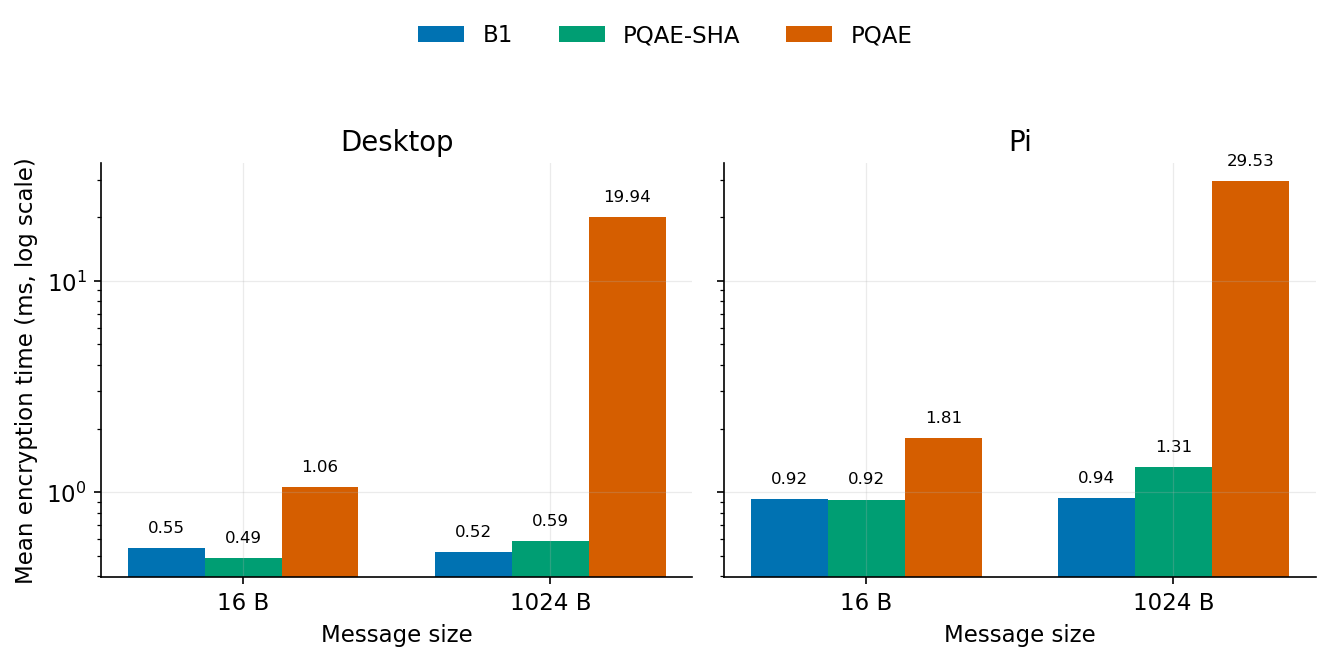

In [ ]:
ablation_rows = [
    # platform, size_B, variant, mean_ms
    ("Desktop", 16,   "B1",       0.546),
    ("Desktop", 16,   "PQAE-SHA", 0.487),
    ("Desktop", 16,   "PQAE",     1.056),
    ("Desktop", 1024, "B1",       0.522),
    ("Desktop", 1024, "PQAE-SHA", 0.586),
    ("Desktop", 1024, "PQAE",     19.940),
    ("Pi",      16,   "B1",       0.924),
    ("Pi",      16,   "PQAE-SHA", 0.923),
    ("Pi",      16,   "PQAE",     1.809),
    ("Pi",      1024, "B1",       0.936),
    ("Pi",      1024, "PQAE-SHA", 1.310),
    ("Pi",      1024, "PQAE",     29.533),
]
df_a = pd.DataFrame(ablation_rows, columns=["platform", "size", "variant", "mean_ms"])

variants = ["B1", "PQAE-SHA", "PQAE"]
variant_colors = {"B1": COLOR_B1, "PQAE-SHA": COLOR_SHA, "PQAE": COLOR_PQAE}
sizes = [16, 1024]

fig, axes = plt.subplots(1, 2, figsize=(9, 4.2), sharey=True)
bar_w = 0.25

for ax, platform in zip(axes, ["Desktop", "Pi"]):
    sub = df_a[df_a["platform"] == platform]
    x = np.arange(len(sizes))
    for i, variant in enumerate(variants):
        vals = [sub[(sub["size"] == s) & (sub["variant"] == variant)]["mean_ms"].iloc[0] for s in sizes]
        bars = ax.bar(x + (i - 1) * bar_w, vals, width=bar_w,
                       label=variant, color=variant_colors[variant])
        for rect, v in zip(bars, vals):
            ax.text(rect.get_x() + rect.get_width() / 2, v * 1.15,
                     f"{v:.2f}", ha="center", va="bottom", fontsize=8)
    ax.set_yscale("log")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{s} B" for s in sizes])
    ax.set_title(platform)
    ax.set_xlabel("Message size")

axes[0].set_ylabel("Mean encryption time (ms, log scale)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.06))
fig.suptitle("")  
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig("ablation_cost.png", bbox_inches="tight")
fig.savefig("ablation_cost.pdf", bbox_inches="tight")
plt.show()

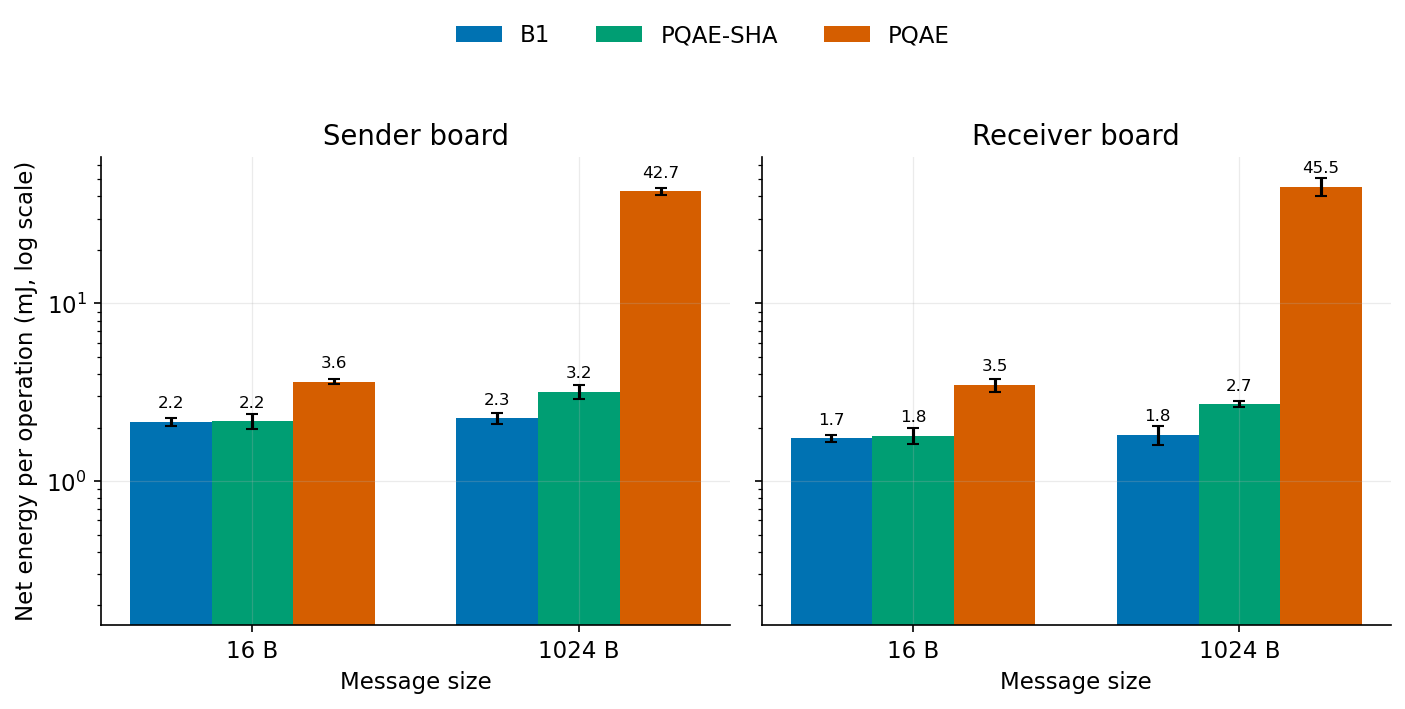

In [ ]:
CSV_PATH = "energy_results_final.csv"  
df_e = pd.read_csv(CSV_PATH)

construction_order = ["baseline", "pqae_sha", "main"]
construction_labels = {"baseline": "B1", "pqae_sha": "PQAE-SHA", "main": "PQAE"}
construction_colors = {"baseline": COLOR_B1, "pqae_sha": COLOR_SHA, "main": COLOR_PQAE}
sizes = [16, 1024]

net = df_e[(df_e.metric == "net_energy_mJ_per_op") & (df_e.construction.isin(construction_order))]

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.5), sharey=True)
bar_w = 0.25

for ax, board in zip(axes, ["sender", "receiver"]):
    sub = net[net.board == board]
    x = np.arange(len(sizes))
    for i, construction in enumerate(construction_order):
        rows = [sub[(sub.size_B == s) & (sub.construction == construction)].iloc[0] for s in sizes]
        means = [r["mean"] for r in rows]
        err_low = [r["mean"] - r["ci_low"] for r in rows]
        err_high = [r["ci_high"] - r["mean"] for r in rows]
        bars = ax.bar(x + (i - 1) * bar_w, means, width=bar_w,
                       yerr=[err_low, err_high], capsize=3,
                       label=construction_labels[construction],
                       color=construction_colors[construction])
        for rect, v in zip(bars, means):
            ax.text(rect.get_x() + rect.get_width() / 2, v * 1.15,
                     f"{v:.1f}", ha="center", va="bottom", fontsize=8)
    ax.set_yscale("log")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{s} B" for s in sizes])
    ax.set_title(f"{board.capitalize()} board")
    ax.set_xlabel("Message size")

axes[0].set_ylabel("Net energy per operation (mJ, log scale)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.06))
fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig("energy_per_operation.png", bbox_inches="tight")
fig.savefig("energy_per_operation.pdf", bbox_inches="tight")
plt.show()